In [1]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.4 MB/s eta 0:00:00


In [2]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00


In [3]:
!pip install pyTsetlinMachineParallel -q

  Preparing metadata (setup.py) ... done


In [31]:
!pip install tmu -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 kB 8.2 MB/s eta 0:00:00


In [4]:
!pip install lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [36]:
# Find and fix the file directly
import subprocess
result = subprocess.run(['find', '/usr/local/lib', '-path', '*/tmu/clause_bank/clause_bank.py'],
                       capture_output=True, text=True)
filepath = result.stdout.strip()
print(f"Found: {filepath}")

with open(filepath, 'r') as f:
    content = f.read()

fixed = content.replace(
    'np.uint32(~0)',
    'np.iinfo(np.uint32).max'
)

with open(filepath, 'w') as f:
    f.write(fixed)

print("Done — restart your runtime now")

Found: /usr/local/lib/python3.12/dist-packages/tmu/clause_bank/clause_bank.py
Done — restart your runtime now


In [1]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import KBinsDiscretizer
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import optuna
import warnings

import lime
import lime.lime_tabular
from pyTsetlinMachineParallel.tm import RegressionTsetlinMachine
import math
from sklearn.linear_model import LinearRegression

In [2]:
from tmu.models.regression.vanilla_regressor import TMRegressor

ERROR:tmu.clause_bank.clause_bank_cuda:No module named 'pycuda'
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tmu/clause_bank/clause_bank_cuda.py", line 41, in <module>
    from pycuda._driver import Device, Context
ModuleNotFoundError: No module named 'pycuda'


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df = pd.read_csv("/content/drive/MyDrive/Forecasting-Agent-for-Fintech/data/macro/volatility_dataset_daily2.csv", parse_dates=["Date"])

In [5]:
df.head()

,PERMNO,Date,BIDLO,ASKHI,PRC,VOL,RET,SHROUT,CFACPR,RETX,...,nfci_risk,nfci_credit,nfci_leverage,nfci_nonfinancial_leverage,gdp,gdp_growth,ppi,unrate,usd_index,trade_balance
0,12490,1990-01-02,94.500,98.125,98.000,1760400.0,0.041169,578847,4.17463,0.041169,...,-0.062462,0.681974,0.425165,0.874241,5872.701,0.02183,114.9,5.4,92.41,-9.757477e+09
1,12490,1990-01-03,98.375,99.500,98.875,2366000.0,0.008929,578847,4.17463,0.008929,...,-0.062462,0.681974,0.425165,0.874241,5872.701,0.02183,114.9,5.4,92.41,-9.757477e+09
2,12490,1990-01-04,98.875,100.375,100.000,2418700.0,0.011378,578847,4.17463,0.011378,...,-0.062462,0.681974,0.425165,0.874241,5872.701,0.02183,114.9,5.4,92.41,-9.757477e+09
3,12490,1990-01-05,99.500,101.625,99.750,1890500.0,-0.002500,578847,4.17463,-0.002500,...,-0.062462,0.681974,0.425165,0.874241,5872.701,0.02183,114.9,5.4,92.41,-9.757477e+09
4,12490,1990-01-08,99.250,100.875,100.375,1156300.0,0.006266,578847,4.17463,0.006266,...,-0.062462,0.681974,0.425165,0.874241,5872.701,0.02183,114.9,5.4,92.41,-9.757477e+09


In [6]:
PARAM_GRIDS = {
    'RF': {
        'model__n_estimators':      [300, 500, 800],
        'model__max_depth':         [3, 5, 7, None],
        'model__min_samples_leaf':  [2, 3, 5],
        'model__min_samples_split': [2, 5, 10],
        'model__max_features':      ['sqrt', 0.5, 0.7],
    },
    'GB': {
        'model__n_estimators':     [200, 300, 500],
        'model__learning_rate':    [0.01, 0.03, 0.05, 0.1],
        'model__max_depth':        [2, 3, 4],
        'model__subsample':        [0.6, 0.7, 0.8],
        'model__min_samples_leaf': [2, 3, 5],
    },
    'XGB': {
        'model__n_estimators':     [300, 500, 800],
        'model__learning_rate':    [0.01, 0.03, 0.05],
        'model__max_depth':        [2, 3, 4],
        'model__subsample':        [0.6, 0.7, 0.8],
        'model__colsample_bytree': [0.6, 0.7, 0.8],
        'model__reg_alpha':        [0.0, 0.1, 0.5, 1.0],
        'model__reg_lambda':       [0.5, 1.0, 2.0],
        'model__min_child_weight': [1, 3, 5],
    },
    'KNN': {
        'model__n_neighbors': [3, 5, 7, 10, 15],
        'model__weights':     ['uniform', 'distance'],
        'model__metric':      ['euclidean', 'manhattan', 'minkowski'],
        'model__leaf_size':   [20, 30, 40],
    },
    'SVR': {
        'model__C':       [0.1, 1.0, 10.0, 50.0, 100.0],
        'model__epsilon': [0.001, 0.01, 0.05, 0.1],
        'model__gamma':   ['scale', 'auto', 0.01, 0.1],
        'model__kernel':  ['rbf', 'linear'],
    },
    'bayes': {
        'model__alpha_1':  [1e-7, 1e-6, 1e-5],
        'model__alpha_2':  [1e-7, 1e-6, 1e-5],
        'model__lambda_1': [1e-7, 1e-6, 1e-5],
        'model__lambda_2': [1e-7, 1e-6, 1e-5],
        'model__max_iter': [300, 500, 1000],
    },
    'catboost': {
        'model__iterations':    [300, 500, 800],
        'model__learning_rate': [0.01, 0.03, 0.05],
        'model__depth':         [3, 4, 5, 6],
        'model__l2_leaf_reg':   [1.0, 3.0, 5.0, 10.0],
        'model__subsample':     [0.6, 0.7, 0.8],
    },
}

BASE_MODELS = {
    'RF':       RandomForestRegressor(random_state=42, n_jobs=-1),
    'GB':       GradientBoostingRegressor(random_state=42),
    'XGB':      XGBRegressor(random_state=42, objective='reg:squarederror',
                             tree_method='hist', verbosity=0),
    'KNN':      KNeighborsRegressor(),
    'SVR':      SVR(),
    'bayes':    BayesianRidge(),
    'catboost': CatBoostRegressor(random_state=42, verbose=0),
}

In [7]:

def tune_model(model_name, pre_steps, X_train, y_train,
               n_iter=30, cv_splits=5):
    steps  = pre_steps + [('model', BASE_MODELS[model_name])]
    pipe   = Pipeline(steps)
    tscv   = TimeSeriesSplit(n_splits=cv_splits)
    search = RandomizedSearchCV(
        estimator          = pipe,
        param_distributions= PARAM_GRIDS[model_name],
        n_iter             = n_iter,
        cv                 = tscv,
        scoring            = 'r2',
        random_state       = 42,
        n_jobs             = -1,
        refit              = True
    )
    search.fit(X_train, y_train)
    print(f"  Best CV R²:  {search.best_score_:.4f}")
    print(f"  Best params: {search.best_params_}")
    return search.best_estimator_


In [8]:
def get_model(model_name):
    models = {
        'RF':       RandomForestRegressor(n_estimators=500, max_depth=5,
                        min_samples_leaf=3, random_state=42, n_jobs=-1),
        'GB':       GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                        max_depth=3, min_samples_leaf=3, subsample=0.8, random_state=42),
        'XGB':      XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=3,
                        subsample=0.7, colsample_bytree=0.7, reg_alpha=0.1,
                        reg_lambda=1.0, random_state=42, objective='reg:squarederror',
                        verbosity=0),
        'KNN':      KNeighborsRegressor(n_neighbors=7, weights='distance'),
        'SVR':      SVR(kernel='rbf', C=10.0, epsilon=0.01, gamma='scale'),
        'bayes':    BayesianRidge(max_iter=500),
        'catboost': CatBoostRegressor(iterations=500, learning_rate=0.03, depth=4,
                        l2_leaf_reg=5.0, random_state=42, verbose=0),
    }
    return models[model_name]


In [9]:
def standard_importance(fitted_model, pipeline, X_train, y_train, feature_names):
    if hasattr(fitted_model, 'feature_importances_'):
        importances = fitted_model.feature_importances_
    elif hasattr(fitted_model, 'coef_'):
        importances = np.abs(fitted_model.coef_)
    else:
        perm        = permutation_importance(pipeline, X_train, y_train,
                                             n_repeats=10, random_state=42)
        importances = perm.importances_mean
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True)

In [10]:
def shap_importance(fitted_model, X_train, feature_names):
    X_train_df  = pd.DataFrame(X_train, columns=feature_names)
    tree_models = (RandomForestRegressor, GradientBoostingRegressor,
                   XGBRegressor, CatBoostRegressor)
    if isinstance(fitted_model, tree_models):
        explainer   = shap.TreeExplainer(fitted_model)
        shap_values = explainer.shap_values(X_train_df)
    else:
        explainer   = shap.KernelExplainer(
            fitted_model.predict, shap.sample(X_train_df, 50))
        shap_values = explainer.shap_values(X_train_df)
    importances = np.abs(shap_values).mean(axis=0)
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True), shap_values, X_train_df

In [11]:

def permutation_importance_ranked(pipeline, X_train, y_train, feature_names):
    perm = permutation_importance(pipeline, X_train, y_train,
                                  n_repeats=20, random_state=42)
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': perm.importances_mean,
        'std':        perm.importances_std
    }).sort_values('importance', ascending=False).reset_index(drop=True)

In [12]:
def plot_macro_bar(fi_df, title):
    fig, ax = plt.subplots(figsize=(7, max(4, len(fi_df) * 0.35)))
    ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1], color='steelblue')
    ax.set_title(title)
    ax.set_xlabel("Importance")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [13]:
def plot_permutation(fi_df, model_name):
    fig, ax = plt.subplots(figsize=(7, max(4, len(fi_df) * 0.35)))
    top = fi_df.head(20)
    ax.barh(top['feature'][::-1], top['importance'][::-1],
            xerr=top['std'][::-1] if 'std' in top.columns else None,
            color='mediumseagreen', capsize=3)
    ax.set_title(f"Permutation Importance — Top 20\n({model_name})")
    ax.set_xlabel("Mean accuracy decrease (±std)")
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [14]:
def plot_shap(shap_values, X_train_df, model_name):
    plt.figure()
    shap.summary_plot(shap_values, X_train_df, plot_type="bar", show=False)
    plt.title(f"SHAP — Mean |SHAP| ({model_name})")
    plt.tight_layout()
    plt.show()

    plt.figure()
    shap.summary_plot(shap_values, X_train_df, show=False)
    plt.title(f"SHAP — Direction & Magnitude ({model_name})")
    plt.tight_layout()
    plt.show()

In [15]:

def lime_importance(fitted_model, X_train, X_test, feature_names, model_name):
    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data        = X_train,
        feature_names        = feature_names,
        mode                 = 'regression',
        discretize_continuous= True,
        random_state         = 42
    )

    n_samples   = min(50, len(X_test))
    sample_idx  = np.linspace(0, len(X_test) - 1, n_samples, dtype=int)
    X_test_sample = X_test[sample_idx]

    all_weights = []
    for i in range(len(X_test_sample)):
        exp          = explainer.explain_instance(
            X_test_sample[i],
            fitted_model.predict,
            num_features = len(feature_names),
            num_samples  = 300
        )
        weights_dict = dict(exp.as_list())
        row          = {f: 0.0 for f in feature_names}
        for key, val in weights_dict.items():
            for fname in feature_names:
                if fname in key:
                    row[fname] = val
                    break
        all_weights.append(row)

    lime_df = pd.DataFrame(all_weights)

    fi_lime = pd.DataFrame({
        'feature':     feature_names,
        'importance':  lime_df.abs().mean().values,
        'mean_effect': lime_df.mean().values,
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(fi_lime.head(20)) * 0.35)))

    top = fi_lime.head(20)
    axes[0].barh(top['feature'][::-1], top['importance'][::-1], color='mediumpurple')
    axes[0].set_title(f"LIME — Mean |Weight| ({model_name})")
    axes[0].set_xlabel("Mean Absolute LIME Weight")
    axes[0].grid(True, alpha=0.3)

    colors = ['tomato' if v < 0 else 'steelblue' for v in top['mean_effect'][::-1]]
    axes[1].barh(top['feature'][::-1], top['mean_effect'][::-1], color=colors)
    axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_title(f"LIME — Direction of Effect ({model_name})\nBlue=increases volatility, Red=decreases volatility")
    axes[1].set_xlabel("Mean Signed LIME Weight")
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"LIME Feature Importance — {model_name}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return fi_lime

In [16]:

def compute_and_plot_importance(strategy, fitted_model, pipeline,
                                X_train, y_train, feature_names,
                                macro_vars, model_name, use_macro,
                                X_test=None):
    run_standard    = strategy in ('standard',    'all')
    run_shap        = strategy in ('shap',        'all')
    run_permutation = strategy in ('permutation', 'all')
    run_lime        = strategy in ('lime',        'all')

    fi_standard = fi_shap = fi_perm = fi_lime = None

    if run_standard:
        fi_standard = standard_importance(fitted_model, pipeline,
                                          X_train, y_train, feature_names)
        macro_fi    = fi_standard[fi_standard['feature'].apply(
                          lambda f: any(f == m or f.startswith(m + "_")
                                        for m in macro_vars))].reset_index(drop=True)
        other_fi    = fi_standard[~fi_standard.index.isin(macro_fi.index)].reset_index(drop=True)
        if use_macro and not macro_fi.empty:
            plot_macro_bar(macro_fi, f"Standard Importance — Macro\n({model_name})")
        if not other_fi.empty:
            plot_macro_bar(other_fi, f"Standard Importance — NASDAQ Features\n({model_name})")

    if run_shap:
        fi_shap, shap_values, X_train_df = shap_importance(fitted_model, X_train, feature_names)
        plot_shap(shap_values, X_train_df, model_name)

    if run_permutation:
        fi_perm = permutation_importance_ranked(pipeline, X_train, y_train, feature_names)
        plot_permutation(fi_perm, model_name)

    if run_lime:
        if X_test is not None:
            fi_lime = lime_importance(fitted_model, X_train, X_test,
                                      feature_names, model_name)
        else:
            print("LIME skipped — X_test not passed to compute_and_plot_importance")

    return fi_standard, fi_shap, fi_perm, fi_lime


In [17]:

def run_arima(y_train, y_test, test_dates, X_train=None, X_test=None, use_macro=False):
    exog_train = X_train if use_macro and X_train is not None else None
    exog_test  = X_test  if use_macro and X_test  is not None else None

    best_result = None
    best_aic    = np.inf

    for p in [1, 2, 5]:
        for d in [0, 1]:
            for q in [0, 1]:
                try:
                    m = SARIMAX(y_train, exog=exog_train,
                                order=(p, d, q),
                                seasonal_order=(1, 0, 0, 5),
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit(disp=False)
                    if m.aic < best_aic:
                        best_aic    = m.aic
                        best_result = m
                except Exception:
                    continue

    predictions = np.array(best_result.forecast(steps=len(y_test), exog=exog_test))
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2   = r2_score(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions) * 100,
    mae  = mean_absolute_error(y_test, predictions)

    results = pd.DataFrame({
        "date":                test_dates.values,
        "actual_volatility":   y_test.values,
        "predicted_volatility": predictions
    })

    print(f"\n{'='*65}")
    print(f"ARIMA — Best AIC: {best_aic:.2f}")

    print(f"{'RMSE:':>45} {rmse:>12.6f}")
    print(f"{'MAE:':>45}  {mae}")
    print(f"{'MAPE (%):':>45} {mape}")
    print(f"{'R²:':>45} {r2}")
    print(f"{'='*65}")
    print("\nNote: ARIMA feature importance not applicable — AR/MA coefficients:")
    print(best_result.params)

    fig, ax = plt.subplots(figsize=(10, 4))
    x = range(len(results))
    ax.plot(x, results["actual_volatility"],    marker="o", label="Actual",    linewidth=2)
    ax.plot(x, results["predicted_volatility"], marker="o", label="Predicted", linewidth=2)
    ax.set_xticks(x[::5])
    ax.set_xticklabels([str(results["date"].iloc[i])[:10]
                        for i in range(0, len(results), 5)], rotation=45)
    ax.set_xlabel("Date")
    ax.set_ylabel("Volatility (annualised)")
    ax.set_title(f"Volatility Prediction — ARIMA\n(R²={r2}  RMSE={rmse} MAE={mae} MAPE={mape}%)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return results, rmse,mae, mape, r2


In [18]:
def run_tsetlin(X_train, X_test, y_train, y_test, test_dates, feature_names, importance_strategy, n_bins=10, epochs=30, tune=True, n_trials=30):
    scaler = RobustScaler()
    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)

    model = XGBRegressor(
        random_state=42,
        objective='reg:squarederror',
        tree_method='hist',
        verbosity=0
    )
    model.fit(X_tr_sc, y_train)
    train_pred = model.predict(X_tr_sc)
    test_pred  = model.predict(X_te_sc)
    base_r2 = r2_score(y_test, test_pred)

    y_train_arr = y_train.to_numpy(dtype=np.float32)
    y_test_arr  = y_test.to_numpy(dtype=np.float32)

    residuals = y_train_arr - train_pred.astype(np.float32)
    resid_mean = float(np.mean(residuals))
    resid_std  = float(np.std(residuals)) if np.std(residuals) > 1e-6 else 1.0

    resid_sc = ((residuals - resid_mean) / resid_std).astype(np.float32)

    print(
        f"Residual range: ±{np.abs(residuals).max():.4f}  "
        f"(vs raw target range ±{np.abs(y_train_arr).max():.4f})"
    )

    booleaniser = KBinsDiscretizer(
        n_bins=n_bins,
        encode='ordinal',
        strategy='quantile'
    )

    X_tr_bits = booleaniser.fit_transform(X_tr_sc).astype(np.uint32)
    X_te_bits = booleaniser.transform(X_te_sc).astype(np.uint32)


    if tune:
        split = int(0.8 * len(X_tr_bits))
        X_opt_tr  = X_tr_bits[:split]
        y_opt_tr  = resid_sc[:split]
        X_opt_val = X_tr_bits[split:]
        y_opt_val = resid_sc[split:]
        y_full_val = y_train_arr[split:]
        base_val   = train_pred[split:].astype(np.float32)
        def objective(trial):
            clauses = trial.suggest_int("number_of_clauses", 200, 4000)
            T       = trial.suggest_int("T", 50, 1000)
            s       = trial.suggest_float("s", 1.5, 10.0)
            tm = TMRegressor(
                number_of_clauses=clauses,
                T=T,
                s=s,
                seed=42,
                weighted_clauses=True
            )
            for _ in range(30):
                tm.fit(X=X_opt_tr, Y=y_opt_tr)
            resid_pred = tm.predict(X_opt_val).astype(np.float32)
            y_pred_val = base_val + (
                resid_pred * resid_std + resid_mean
            )
            return math.sqrt(
                mean_squared_error(y_full_val, y_pred_val)
            )
        print(f"\nRunning Optuna ({n_trials} trials)...")

        study = optuna.create_study(
            direction="minimize",
            sampler=optuna.samplers.TPESampler(seed=42)
        )
        study.optimize(
            objective,
            n_trials=n_trials,
            show_progress_bar=True
        )
        best = study.best_params
        print(
            f"Best params: {best}  |  "
            f"Best val RMSE: {study.best_value:.4f}"
        )

    else:
        best = {
            "number_of_clauses": 1000,
            "T": 300,
            "s": 5.0
        }
    tm = TMRegressor(
        **best,
        seed=42,
        weighted_clauses=True
    )
    for _ in range(epochs):
        tm.fit(X=X_tr_bits, Y=resid_sc)
    resid_pred_te = tm.predict(X_te_bits).astype(np.float32)
    tm_correction = (
        resid_pred_te * resid_std + resid_mean
    )
    clip_val = float(np.abs(residuals).max()) * 2.0
    tm_correction = np.clip(
        tm_correction,
        -clip_val,
        clip_val
    )

    y_pred = (
        test_pred.astype(np.float32)
        + 0.2 * tm_correction
    )
    resid_pred_tr = tm.predict(X_tr_bits).astype(np.float32)
    y_pred_tr = (
        train_pred.astype(np.float32)
        + np.clip(
            resid_pred_tr * resid_std + resid_mean,
            -clip_val,
            clip_val
        )
    )
    calibrator = LinearRegression()
    calibrator.fit(
        y_pred_tr.reshape(-1, 1),
        y_train_arr
    )

    y_pred = calibrator.predict(
        y_pred.reshape(-1, 1)
    ).ravel().astype(np.float32)

    rmse = math.sqrt(mean_squared_error(y_test_arr, y_pred))
    mae  = mean_absolute_error(y_test_arr, y_pred)
    mape = mean_absolute_percentage_error(y_test_arr, y_pred) * 100
    r2   = r2_score(y_test_arr, y_pred)
    results = pd.DataFrame({
        "date": test_dates.values,
        "actual": y_test_arr,
        "xgb_base_prediction": test_pred,
        "predicted_volatility": y_pred
    })
    fi_perm = None

    if importance_strategy == "xgb_gain":
        fi_perm = pd.DataFrame({
            "feature": feature_names,
            "importance": model.feature_importances_
        }).sort_values("importance", ascending=False)

    print(f"{'MAE:':>45} {mae:>12.4f}")
    print(f"{'RMSE:':>45} {rmse:>12.4f}")
    print(f"{'MAPE (%):':>45} {mape:>12.2f}")
    print(f"{'R²:':>45} {r2:>12.4f}")

    # ============================================================
    # Plot
    # ============================================================
    fig, ax = plt.subplots(figsize=(10, 4))

    x = range(len(results))

    ax.plot(
        x,
        results["actual"],
        marker="o",
        label="Actual",
        linewidth=2
    )

    ax.plot(
        x,
        test_pred,
        marker="s",
        label="XGBoost Base",
        linewidth=1.5,
        linestyle="--",
        alpha=0.6
    )

    ax.plot(
        x,
        results["predicted_volatility"],
        marker="o",
        label="TM Corrected",
        linewidth=2
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        [str(d)[:10] for d in results["date"]],
        rotation=45
    )

    ax.set_xlabel("Date")
    ax.set_ylabel("Target")

    ax.set_title(
        f"XGBoost + Tsetlin Residual Correction\n"
        f"Base R²={base_r2:.3f}  →  Final R²={r2:.3f}  "
        f"RMSE={rmse:.4f}  MAPE={mape:.1f}%"
    )

    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return results, rmse, mae, mape, r2, fi_perm

In [19]:
macro_vars = [
        "b30ret","b20ret","b10ret","b7ret","b5ret","b2ret","b1ret",
        "t90ret","t30ret","cpiret","wti_price","fedfunds","nfci","anfci",
        "nfci_risk","nfci_credit","nfci_leverage","nfci_nonfinancial_leverage",
        "gdp","ppi","trade_balance","unrate","usd_index"
    ]
def Volatility_prediction(data, use_macro, model,
                          use_scaling, test_days=252,
                          use_lags=True, use_rolling=True,
                          volatility_window=21,
                          feature_selection=False, n_features=15,
                          importance_strategy='standard',
                          tune=True, n_iter=30, cv_splits=5):

    df = data.copy().sort_values("Date").reset_index(drop=True)
    df = df.rename(columns={"Date": "date"})
    df["date"] = pd.to_datetime(df["date"])

    df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
    df["volatility"] = (
        df["log_return"].shift(1)
        .rolling(volatility_window)
        .std() * np.sqrt(252)
    )
    df["daily_range"]   = (df["High"] - df["Low"]) / df["Close"]
    df["volume_change"] = df["Volume"].pct_change()
    df["close_lag1"]    = df["Close"].shift(1)
    df["return_lag1"]   = df["log_return"].shift(1)

    df = df.dropna(subset=["volatility"]).reset_index(drop=True)

    if use_lags:
        for lag in [1, 2, 3, 5, 10]:
            df[f"volatility_lag{lag}"] = df["volatility"].shift(lag)
        for col in macro_vars:
            if col in df.columns:
                df[f"{col}_lag1"] = df[col].shift(1)

    if use_rolling:
        for w in [5, 10, 21]:
            df[f"volatility_roll{w}"] = df["volatility"].shift(1).rolling(w).mean()

    df = df.dropna().reset_index(drop=True)
    dates = df["date"]

    drop_price_cols = ["Close", "High", "Low", "Open", "Volume", "log_return"]
    X = df.drop(columns=["volatility", "date"] + drop_price_cols, errors="ignore")
    y = df["volatility"]

    if not use_macro:
        drop_cols = macro_vars + [c for c in X.columns
                                  if any(c.startswith(m) for m in macro_vars)]
        X = X.drop(columns=drop_cols, errors="ignore")

    X_train       = X.iloc[:-test_days]
    X_test        = X.iloc[-test_days:]
    y_train       = y.iloc[:-test_days]
    y_test        = y.iloc[-test_days:]
    test_dates    = dates.iloc[-test_days:]
    feature_names = X.columns.tolist()

    print(f"Total: {len(X)} | Train: {len(X_train)} | Test: {len(X_test)} | Features: {len(feature_names)}")
    print(feature_names)

    if model == 'arima':
        return run_arima(y_train, y_test, test_dates,
                         X_train.values if use_macro else None,
                         X_test.values  if use_macro else None,
                         use_macro)

    if model == 'tsetlin':
        return run_tsetlin(X_train.values, X_test.values,
                           y_train, y_test, test_dates,
                           feature_names, importance_strategy,
                           tune=tune, n_trials=n_iter)

    pre_steps = []
    if use_scaling:
        pre_steps.append(('scaler', RobustScaler()))
    if feature_selection:
        pre_steps.append(('selector', SelectKBest(f_regression,
                                                   k=min(n_features, X.shape[1]))))

    if tune and model in PARAM_GRIDS:
        print(f"\nTuning {model} with TimeSeriesSplit (n_iter={n_iter}, cv={cv_splits})...")
        best_pipeline = tune_model(model, pre_steps, X_train, y_train,
                                   n_iter=n_iter, cv_splits=cv_splits)
    else:
        steps = pre_steps + [('model', get_model(model))]
        best_pipeline = Pipeline(steps)
        best_pipeline.fit(X_train, y_train)

    predictions  = best_pipeline.predict(X_test)
    fitted_model = best_pipeline.named_steps['model']

    mse  = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions) * 100
    mae  = mean_absolute_error(y_test, predictions)

    results = pd.DataFrame({
        "date":                test_dates.values,
        "actual_volatility":   y_test.values,
        "predicted_volatility": predictions
    })

    print(f"\n{'='*65}")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
    print(f"{'-'*65}")
    for _, row in results.iloc[::21].iterrows():
        error = abs(row['actual_volatility'] - row['predicted_volatility'])
        print(f"{str(row['date'])[:10]:<15} {row['actual_volatility']:>12.6f} {row['predicted_volatility']:>12.6f} {error:>12.6f}")
    print(f"  (showing every ~21 days)")
    print(f"{'-'*65}")
    print(f"{'RMSE:':>45} {rmse:>12.6f}")
    print(f"{'MAE:':>45}  {mae:>12.4f}")
    print(f"{'MAPE (%):':>45} {mape:>12.2f}")
    print(f"{'R²:':>45} {r2:>12.4f}")
    print(f"{'='*65}")

    if feature_selection:
        selected_mask   = best_pipeline.named_steps['selector'].get_support()
        feat_names_used = [f for f, s in zip(feature_names, selected_mask) if s]
        X_train_arr     = best_pipeline[:-1].transform(X_train)
    else:
        feat_names_used = feature_names
        X_train_arr     = best_pipeline[:-1].transform(X_train) if use_scaling else X_train.values

    fig_pred, ax_pred = plt.subplots(figsize=(12, 4))
    ax_pred.plot(results["date"], results["actual_volatility"],
                 label="Actual",    linewidth=1.5)
    ax_pred.plot(results["date"], results["predicted_volatility"],
                 label="Predicted", linewidth=1.5, alpha=0.8)
    ax_pred.xaxis.set_major_locator(plt.MaxNLocator(10))
    plt.xticks(rotation=45)
    ax_pred.set_xlabel("Date")
    ax_pred.set_ylabel("Volatility (annualised)")
    tuned_label = "Tuned" if tune else "Default"
    ax_pred.set_title(f"Daily Volatility Prediction — {model} ({tuned_label})\n(R²={r2:.3f}  RMSE={rmse:.6f} MAE={mae:.4f} MAPE={mape:.1f}%)")
    ax_pred.legend()
    ax_pred.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    X_test_arr = best_pipeline[:-1].transform(X_test) if use_scaling else X_test.values

    fi_standard, fi_shap, fi_perm, fi_lime = compute_and_plot_importance(
        strategy      = importance_strategy,
        fitted_model  = fitted_model,
        pipeline      = best_pipeline,
        X_train       = X_train_arr,
        y_train       = y_train,
        feature_names = feat_names_used,
        macro_vars    = macro_vars,
        model_name    = model,
        use_macro     = use_macro,
        X_test        = X_test_arr
    )

    return results, rmse, mae,  mape, r2, fi_standard, fi_shap, fi_perm, fi_lime



### Tselin

Total: 8774 | Train: 8522 | Test: 252 | Features: 22
['PERMNO', 'BIDLO', 'ASKHI', 'PRC', 'VOL', 'RET', 'SHROUT', 'CFACPR', 'RETX', 'sprtrn', 'daily_range', 'volume_change', 'close_lag1', 'return_lag1', 'volatility_lag1', 'volatility_lag2', 'volatility_lag3', 'volatility_lag5', 'volatility_lag10', 'volatility_roll5', 'volatility_roll10', 'volatility_roll21']


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:262: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 7 are removed. Consider decreasing the number of bins.
  warnings.warn(
[I 2026-05-16 12:48:10,535] A new study created in memory with name: no-name-c6dab957-2283-40cc-b247-46b3b2958480


Residual range: ±0.0332  (vs raw target range ±0.9567)

Running Optuna (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-05-16 12:48:46,919] Trial 0 finished with value: 0.01584412822710442 and parameters: {'number_of_clauses': 1623, 'T': 954, 's': 7.721948505396943}. Best is trial 0 with value: 0.01584412822710442.
[I 2026-05-16 12:49:05,946] Trial 1 finished with value: 0.13493818486010292 and parameters: {'number_of_clauses': 2475, 'T': 198, 's': 2.8259534228577223}. Best is trial 0 with value: 0.01584412822710442.
[I 2026-05-16 12:49:15,865] Trial 2 finished with value: 0.009527993193588692 and parameters: {'number_of_clauses': 420, 'T': 873, 's': 6.609477599817275}. Best is trial 2 with value: 0.009527993193588692.
[I 2026-05-16 12:49:35,101] Trial 3 finished with value: 0.48270712075913275 and parameters: {'number_of_clauses': 2891, 'T': 69, 's': 9.744233743376952}. Best is trial 2 with value: 0.009527993193588692.
[I 2026-05-16 12:49:56,640] Trial 4 finished with value: 0.14931058105123451 and parameters: {'number_of_clauses': 3364, 'T': 251, 's': 3.0455122212603554}. Best is trial 2 with 

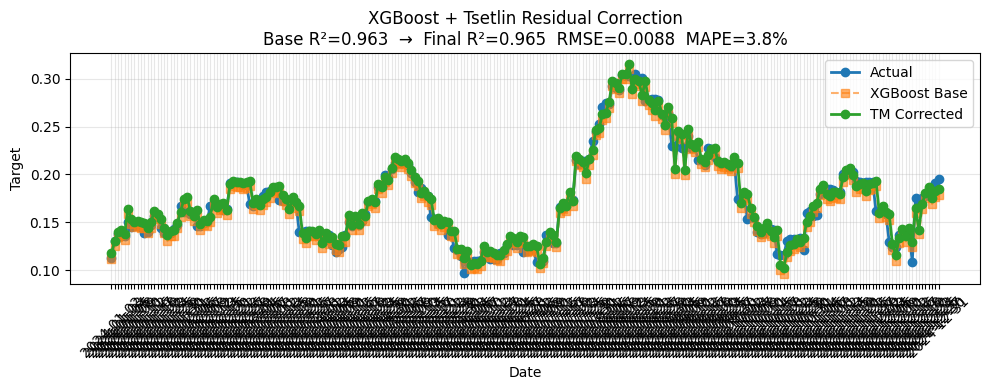

In [21]:
results, rmse, mae, mape, r2, tselin_fi_perm = Volatility_prediction(
    df, use_macro=False, model='tsetlin',
    use_scaling=True, importance_strategy='lime'
)

Total: 8774 | Train: 8522 | Test: 252 | Features: 69
['PERMNO', 'BIDLO', 'ASKHI', 'PRC', 'VOL', 'RET', 'SHROUT', 'CFACPR', 'RETX', 'sprtrn', 'b30ret', 'b20ret', 'b10ret', 'b7ret', 'b5ret', 'b2ret', 'b1ret', 't90ret', 't30ret', 'cpiret', 'wti_price', 'fedfunds', 'nfci', 'anfci', 'nfci_risk', 'nfci_credit', 'nfci_leverage', 'nfci_nonfinancial_leverage', 'gdp', 'gdp_growth', 'ppi', 'unrate', 'usd_index', 'trade_balance', 'daily_range', 'volume_change', 'close_lag1', 'return_lag1', 'volatility_lag1', 'volatility_lag2', 'volatility_lag3', 'volatility_lag5', 'volatility_lag10', 'b30ret_lag1', 'b20ret_lag1', 'b10ret_lag1', 'b7ret_lag1', 'b5ret_lag1', 'b2ret_lag1', 'b1ret_lag1', 't90ret_lag1', 't30ret_lag1', 'cpiret_lag1', 'wti_price_lag1', 'fedfunds_lag1', 'nfci_lag1', 'anfci_lag1', 'nfci_risk_lag1', 'nfci_credit_lag1', 'nfci_leverage_lag1', 'nfci_nonfinancial_leverage_lag1', 'gdp_lag1', 'ppi_lag1', 'trade_balance_lag1', 'unrate_lag1', 'usd_index_lag1', 'volatility_roll5', 'volatility_roll10'

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:262: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 7 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 29 are removed. Consider decreasing the number of bins.
  warnings.warn(
[I 2026-05-16 12:56:09,581] A new study created in memory with name: no-name-fa70d2ac-b6af-432d-9a3c-b24326f24d1b


Residual range: ±0.0279  (vs raw target range ±0.9567)

Running Optuna (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-05-16 12:56:30,740] Trial 0 finished with value: 0.007071196600595695 and parameters: {'number_of_clauses': 1623, 'T': 954, 's': 7.721948505396943}. Best is trial 0 with value: 0.007071196600595695.
[I 2026-05-16 12:56:56,151] Trial 1 finished with value: 0.11735152844834283 and parameters: {'number_of_clauses': 2475, 'T': 198, 's': 2.8259534228577223}. Best is trial 0 with value: 0.007071196600595695.
[I 2026-05-16 12:57:08,684] Trial 2 finished with value: 0.006749010226041227 and parameters: {'number_of_clauses': 420, 'T': 873, 's': 6.609477599817275}. Best is trial 2 with value: 0.006749010226041227.
[I 2026-05-16 12:57:36,046] Trial 3 finished with value: 0.4022718013393735 and parameters: {'number_of_clauses': 2891, 'T': 69, 's': 9.744233743376952}. Best is trial 2 with value: 0.006749010226041227.
[I 2026-05-16 12:58:07,756] Trial 4 finished with value: 0.12324714257727198 and parameters: {'number_of_clauses': 3364, 'T': 251, 's': 3.0455122212603554}. Best is trial 2 wit

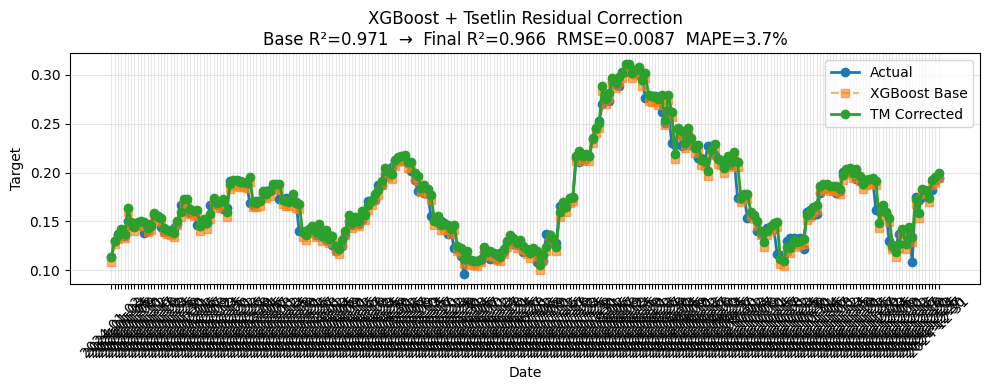

In [22]:
results, rmse, mae, mape, r2, tselin_fi_perm = Volatility_prediction(
    df, use_macro=True, model='tsetlin',
    use_scaling=True,
    importance_strategy='lime', tune = True
)

### bayes

Total: 8774 | Train: 8522 | Test: 252 | Features: 12

Tuning bayes with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²:  0.9831
  Best params: {'model__max_iter': 1000, 'model__lambda_2': 1e-05, 'model__lambda_1': 1e-07, 'model__alpha_2': 1e-07, 'model__alpha_1': 1e-05}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.112578     0.000642
2024-02-01          0.167210     0.147042     0.020168
2024-03-04          0.169070     0.186730     0.017660
2024-04-03          0.135562     0.134550     0.001012
2024-05-02          0.197198     0.201939     0.004741
2024-06-03          0.121509     0.125370     0.003861
2024-07-03          0.119741     0.121500     0.001760
2024-08-02          0.244631     0.238473     0.006158
2024-09-03          0.251129     0.265597     0.014468
2024-10-02          0.212546     0.204350     0.008196
2024-10-31          0.121384     0.136817     0.015432

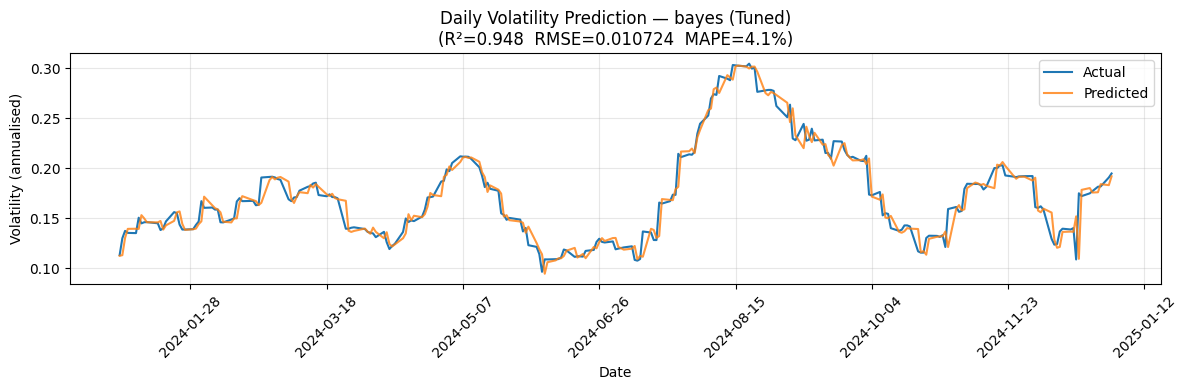

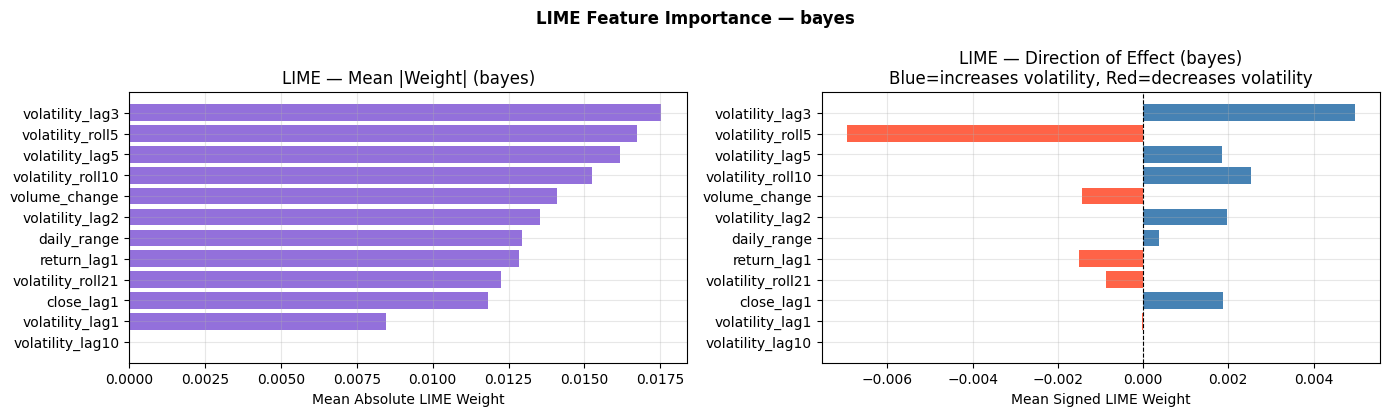

In [ ]:
results, rmse, mae, mape, r2, bayes_fi_std, bayes_fi_shap, bayes_fi_perm, bayes_fi_lime = Volatility_prediction(
    df, use_macro=False, model='bayes',
    use_scaling=True, importance_strategy='lime'
)

Total: 8774 | Train: 8522 | Test: 252 | Features: 59

Tuning bayes with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²:  0.9794
  Best params: {'model__max_iter': 500, 'model__lambda_2': 1e-07, 'model__lambda_1': 1e-05, 'model__alpha_2': 1e-05, 'model__alpha_1': 1e-07}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.103658     0.009562
2024-02-01          0.167210     0.149368     0.017842
2024-03-04          0.169070     0.185626     0.016556
2024-04-03          0.135562     0.135899     0.000337
2024-05-02          0.197198     0.202699     0.005501
2024-06-03          0.121509     0.131027     0.009518
2024-07-03          0.119741     0.125194     0.005453
2024-08-02          0.244631     0.238436     0.006195
2024-09-03          0.251129     0.259573     0.008445
2024-10-02          0.212546     0.203440     0.009106
2024-10-31          0.121384     0.136206     0.014822


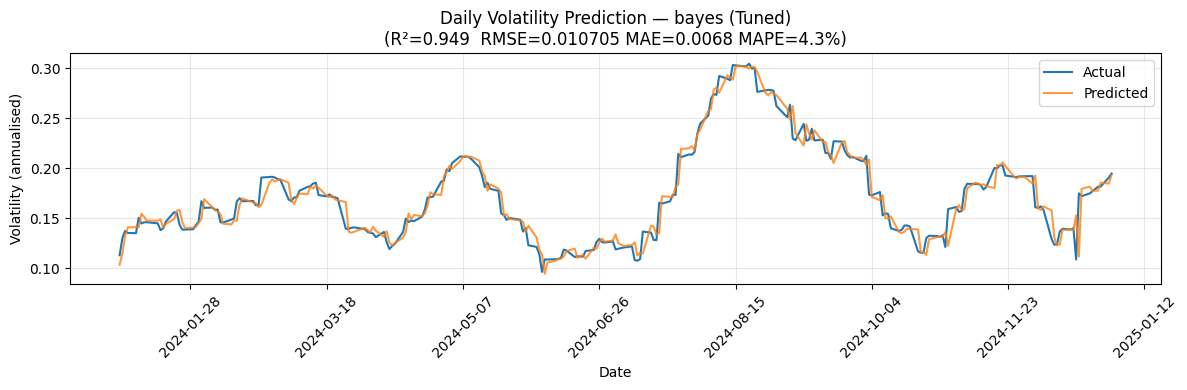

  0%|          | 0/8522 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
results, rmse, mae, mape, r2, bayes_fi_std, bayes_fi_shap, bayes_fi_perm, bayes_fi_lime = Volatility_prediction(
    df, use_macro=True, model='bayes',
    use_scaling=True, importance_strategy='shap'
)

### Random Forest

Total: 8774 | Train: 8522 | Test: 252 | Features: 12

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.111938     0.001282
2024-02-01          0.167210     0.151155     0.016055
2024-03-04          0.169070     0.186575     0.017505
2024-04-03          0.135562     0.137093     0.001531
2024-05-02          0.197198     0.200248     0.003051
2024-06-03          0.121509     0.126101     0.004592
2024-07-03          0.119741     0.116067     0.003674
2024-08-02          0.244631     0.234472     0.010159
2024-09-03          0.251129     0.258319     0.007191
2024-10-02          0.212546     0.206088     0.006459
2024-10-31          0.121384     0.131299     0.009915
2024-12-02          0.192293     0.186850     0.005444
  (showing every ~21 days)
-----------------------------------------------------------------
                                        RMSE:     0.010632
             

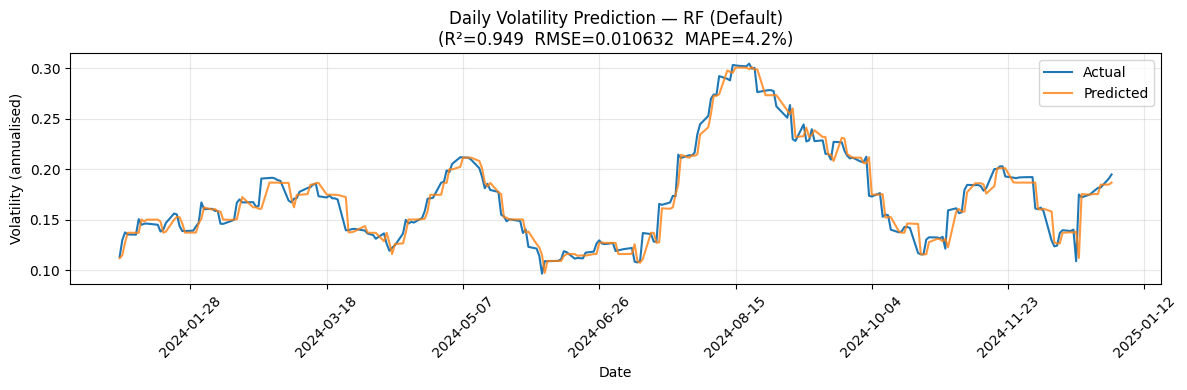

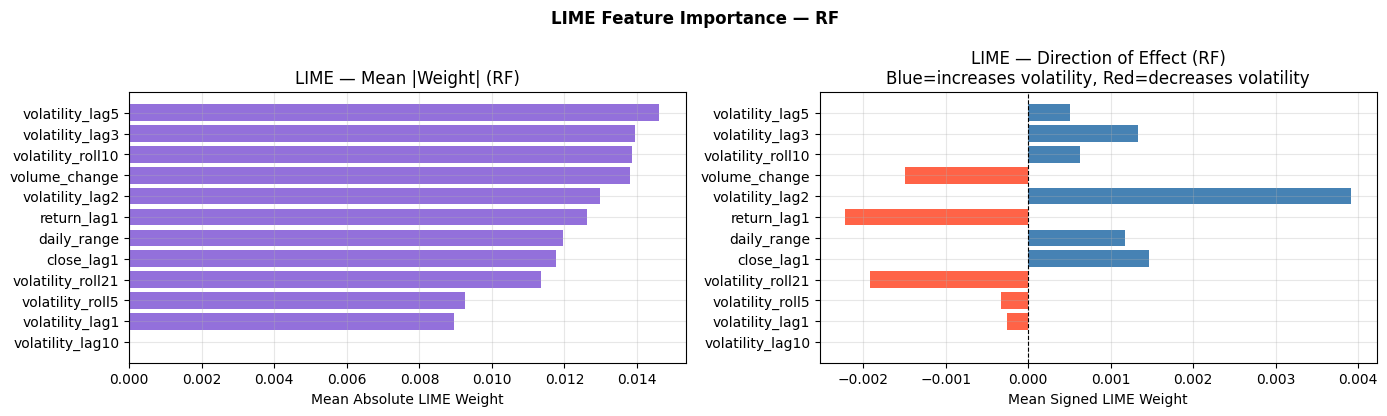

In [ ]:
results, rmse, mae, mape, r2, rf_fi_std, rf_fi_shap, rf_fi_perm, rf_fi_lime = Volatility_prediction(
    df, use_macro=False, model='RF',
    use_scaling=True, importance_strategy='lime',
    tune=False
)

Total: 8774 | Train: 8522 | Test: 252 | Features: 59

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.111938     0.001282
2024-02-01          0.167210     0.151155     0.016055
2024-03-04          0.169070     0.186575     0.017505
2024-04-03          0.135562     0.137093     0.001531
2024-05-02          0.197198     0.200248     0.003051
2024-06-03          0.121509     0.126101     0.004592
2024-07-03          0.119741     0.116067     0.003674
2024-08-02          0.244631     0.234472     0.010159
2024-09-03          0.251129     0.258319     0.007191
2024-10-02          0.212546     0.206088     0.006459
2024-10-31          0.121384     0.131299     0.009915
2024-12-02          0.192293     0.186850     0.005444
  (showing every ~21 days)
-----------------------------------------------------------------
                                        RMSE:     0.010632
             

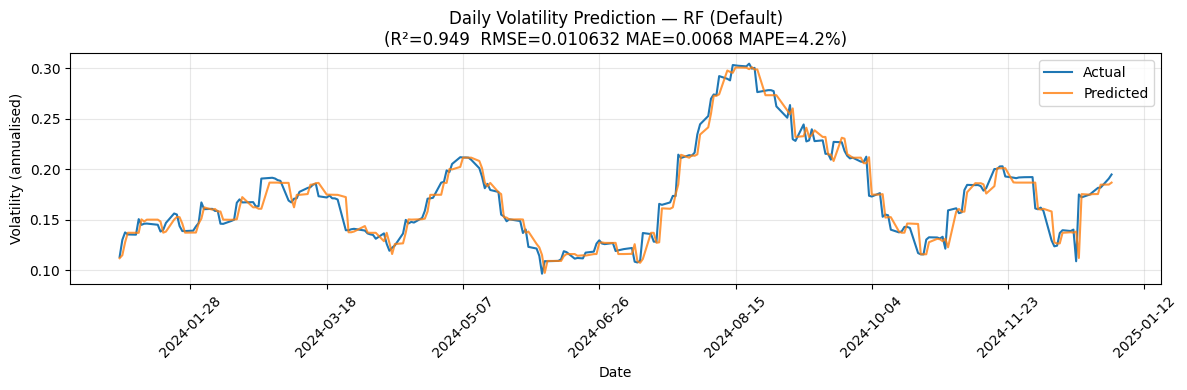

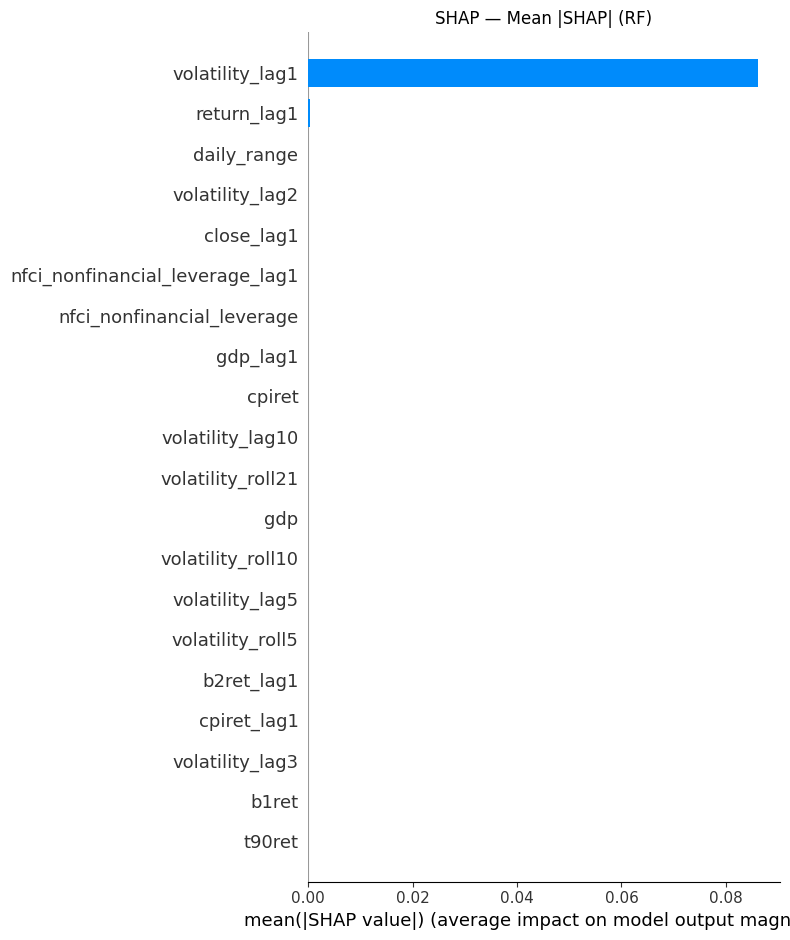

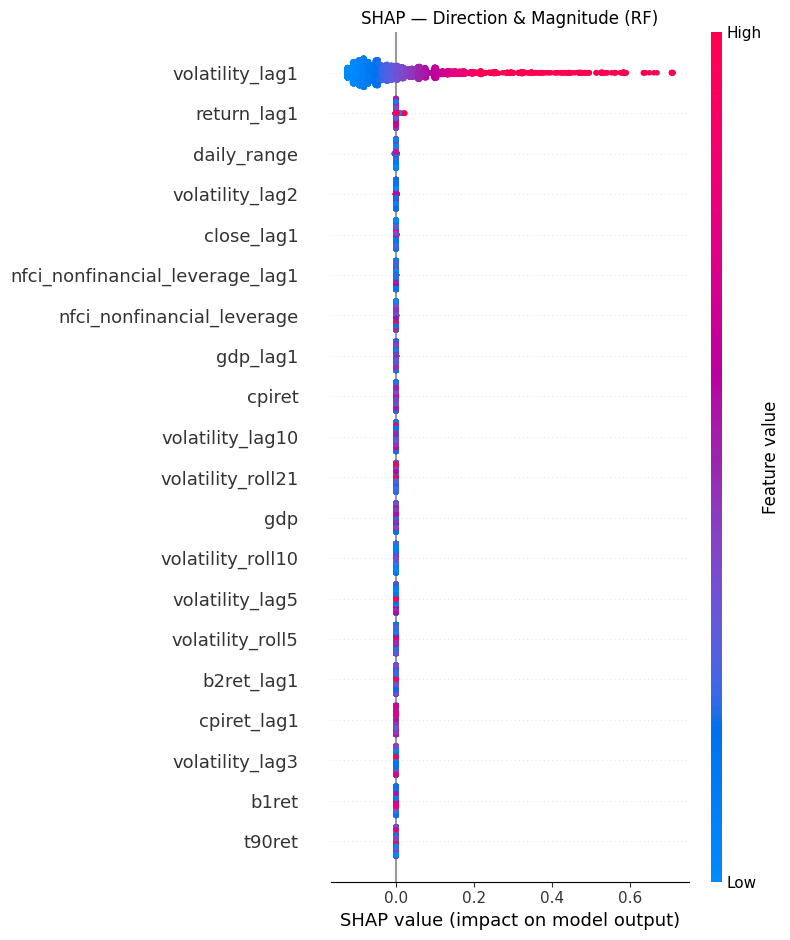

In [ ]:

results, rmse, mae, mape, r2, rf_fi_std, rf_fi_shap, rf_fi_perm, rf_fi_lime = Volatility_prediction(
    df, use_macro=True, model='RF',
    use_scaling=True, importance_strategy='shap',
    tune=False
)

### GB

Total: 8774 | Train: 8522 | Test: 252 | Features: 12

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.108334     0.004886
2024-02-01          0.167210     0.162510     0.004700
2024-03-04          0.169070     0.187008     0.017938
2024-04-03          0.135562     0.137181     0.001619
2024-05-02          0.197198     0.194414     0.002783
2024-06-03          0.121509     0.120739     0.000770
2024-07-03          0.119741     0.118474     0.001267
2024-08-02          0.244631     0.243282     0.001349
2024-09-03          0.251129     0.257177     0.006048
2024-10-02          0.212546     0.208479     0.004068
2024-10-31          0.121384     0.129965     0.008581
2024-12-02          0.192293     0.186929     0.005365
  (showing every ~21 days)
-----------------------------------------------------------------
                                        RMSE:     0.006964
             

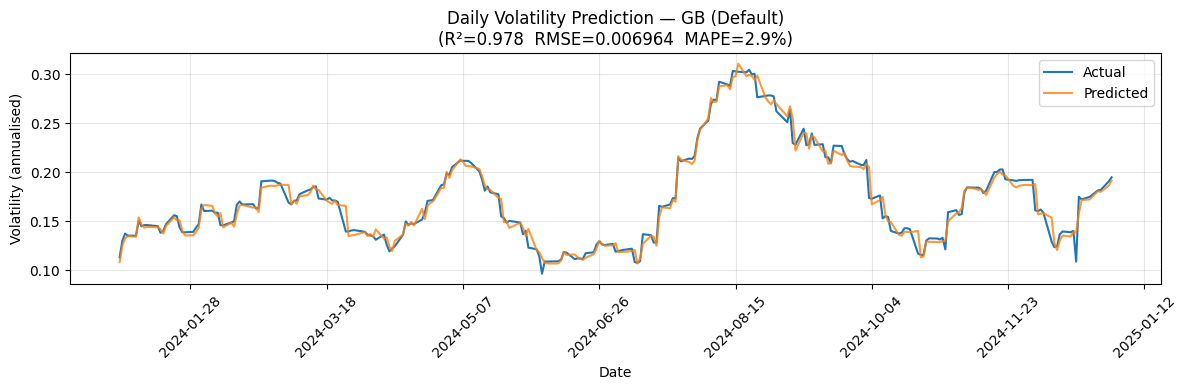

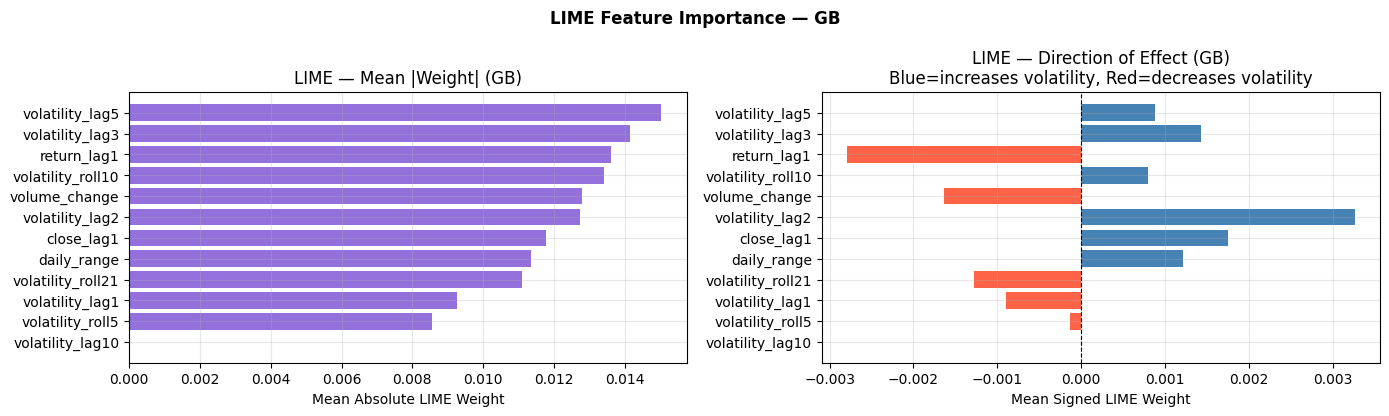

In [ ]:
results, rmse, mae, mape, r2, gb_fi_std, gb_fi_shap, gb_fi_perm, gb_fi_lime = Volatility_prediction(
    df, use_macro=False, model='GB',
    use_scaling=True, importance_strategy='lime', tune=False
)

Total: 8774 | Train: 8522 | Test: 252 | Features: 59

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.108495     0.004725
2024-02-01          0.167210     0.163423     0.003787
2024-03-04          0.169070     0.186870     0.017800
2024-04-03          0.135562     0.136985     0.001423
2024-05-02          0.197198     0.194465     0.002732
2024-06-03          0.121509     0.120597     0.000913
2024-07-03          0.119741     0.118346     0.001395
2024-08-02          0.244631     0.243414     0.001217
2024-09-03          0.251129     0.257416     0.006287
2024-10-02          0.212546     0.208357     0.004190
2024-10-31          0.121384     0.129546     0.008162
2024-12-02          0.192293     0.186979     0.005315
  (showing every ~21 days)
-----------------------------------------------------------------
                                        RMSE:     0.007000
             

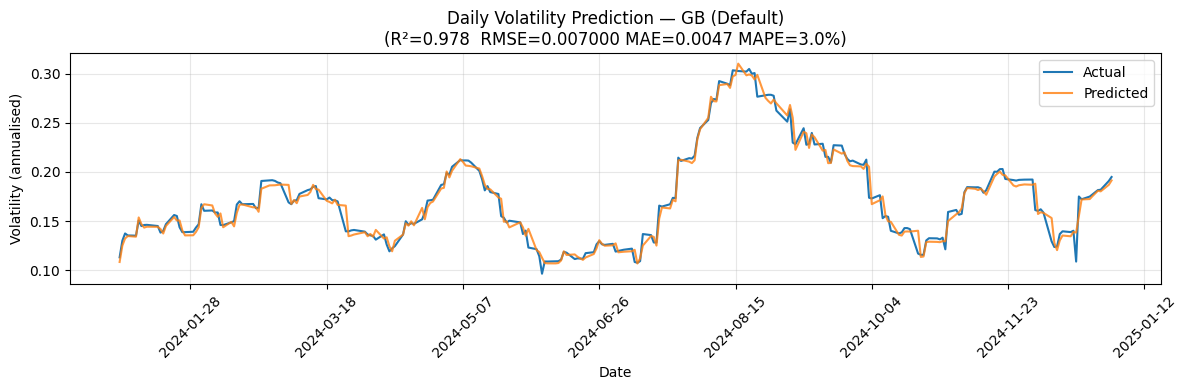

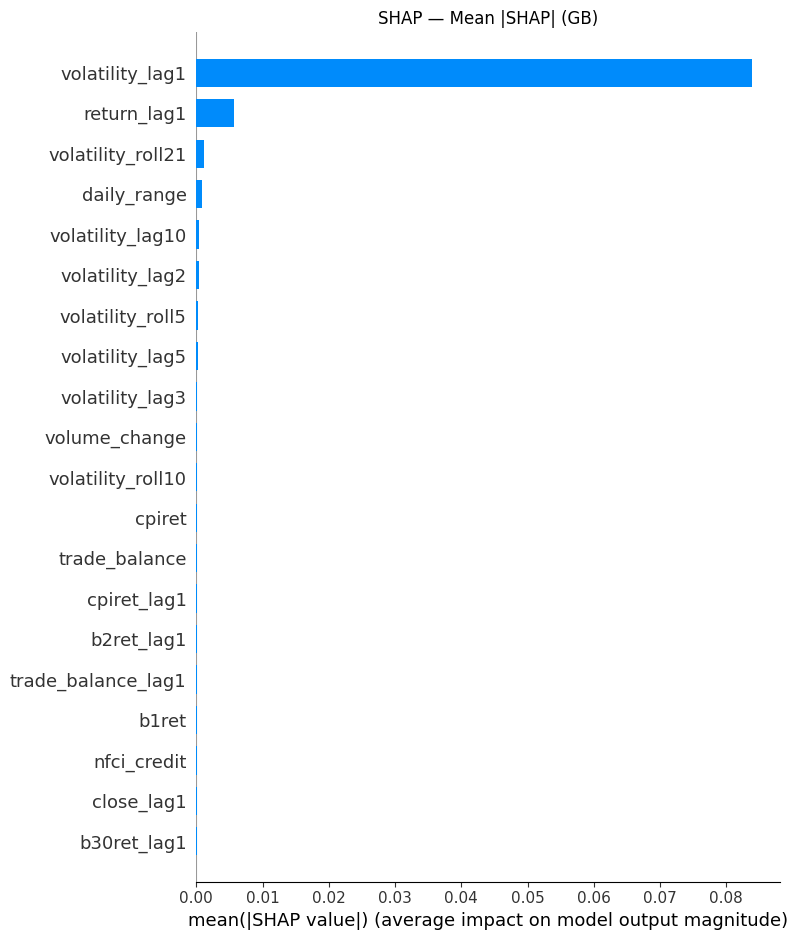

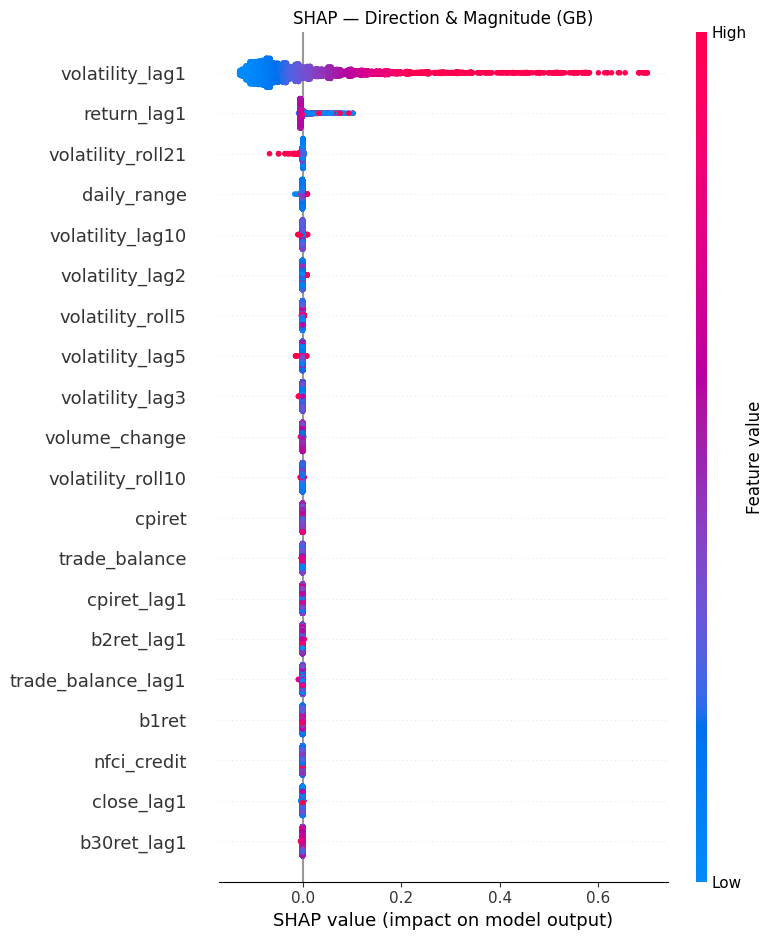

In [ ]:
results, rmse, mae, mape, r2, gb_fi_std, gb_fi_shap, gb_fi_perm, gb_fi_lime = Volatility_prediction(
    df, use_macro=True, model='GB',
    use_scaling=True, importance_strategy='shap', tune = False
)

### XGB

Total: 8774 | Train: 8522 | Test: 252 | Features: 12

Tuning XGB with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²:  0.8684
  Best params: {'model__subsample': 0.7, 'model__reg_lambda': 0.5, 'model__reg_alpha': 0.0, 'model__n_estimators': 500, 'model__min_child_weight': 3, 'model__max_depth': 2, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.110620     0.002600
2024-02-01          0.167210     0.159621     0.007589
2024-03-04          0.169070     0.188204     0.019134
2024-04-03          0.135562     0.137114     0.001552
2024-05-02          0.197198     0.190931     0.006266
2024-06-03          0.121509     0.127552     0.006042
2024-07-03          0.119741     0.120061     0.000321
2024-08-02          0.244631     0.233458     0.011173
2024-09-03          0.251129     0.261421     0.010292
2024-10-02         

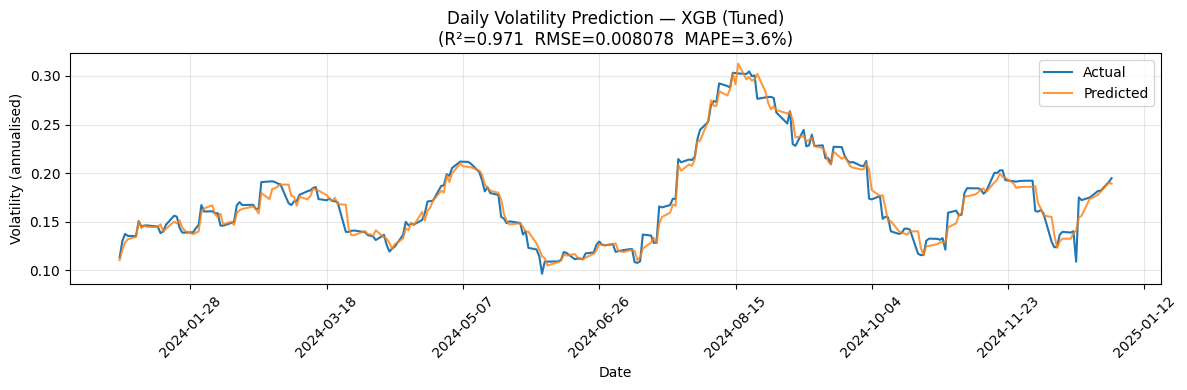

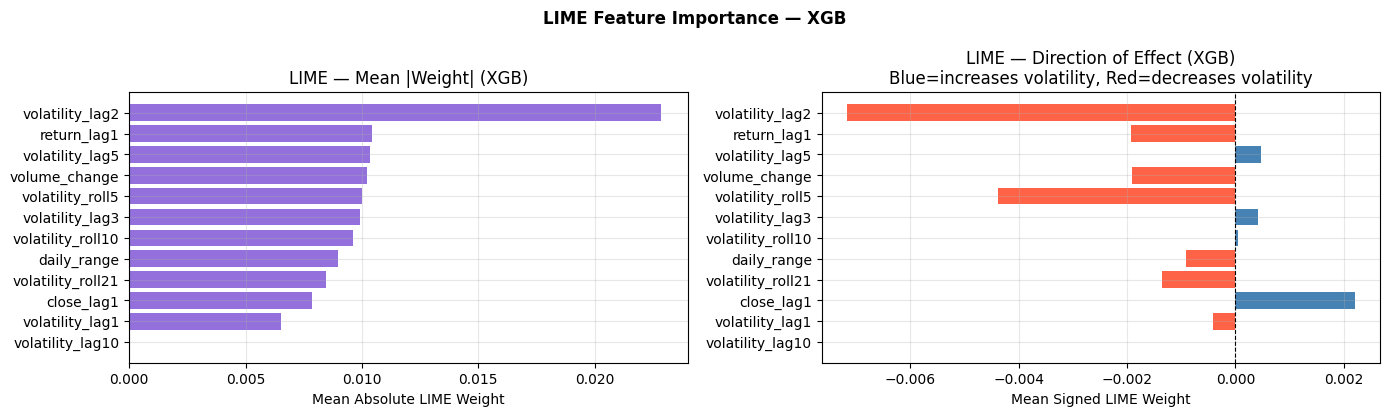

In [ ]:
results, rmse, mae, mape, r2, xgb_fi_std, xgb_fi_shap, xgb_fi_perm, xgb_fi_lime = Volatility_prediction(
    df,
    use_macro        = False,
    model            = 'XGB',
    use_scaling      = True,
    importance_strategy = 'shap',
    tune=False
)

Total: 8774 | Train: 8522 | Test: 252 | Features: 59

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.110133     0.003087
2024-02-01          0.167210     0.162155     0.005055
2024-03-04          0.169070     0.188019     0.018949
2024-04-03          0.135562     0.136166     0.000604
2024-05-02          0.197198     0.192181     0.005017
2024-06-03          0.121509     0.124457     0.002948
2024-07-03          0.119741     0.120704     0.000963
2024-08-02          0.244631     0.238222     0.006408
2024-09-03          0.251129     0.259935     0.008807
2024-10-02          0.212546     0.208586     0.003960
2024-10-31          0.121384     0.130221     0.008837
2024-12-02          0.192293     0.186922     0.005371
  (showing every ~21 days)
-----------------------------------------------------------------
                                        RMSE:     0.007329
             

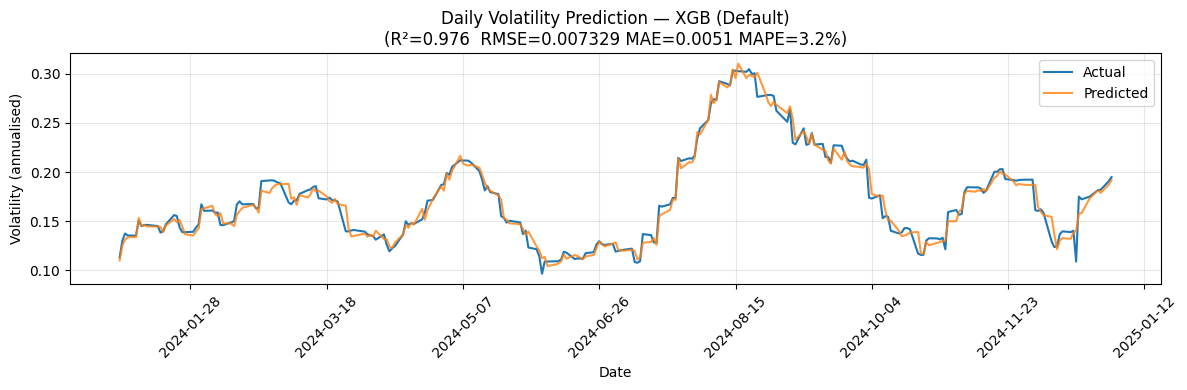

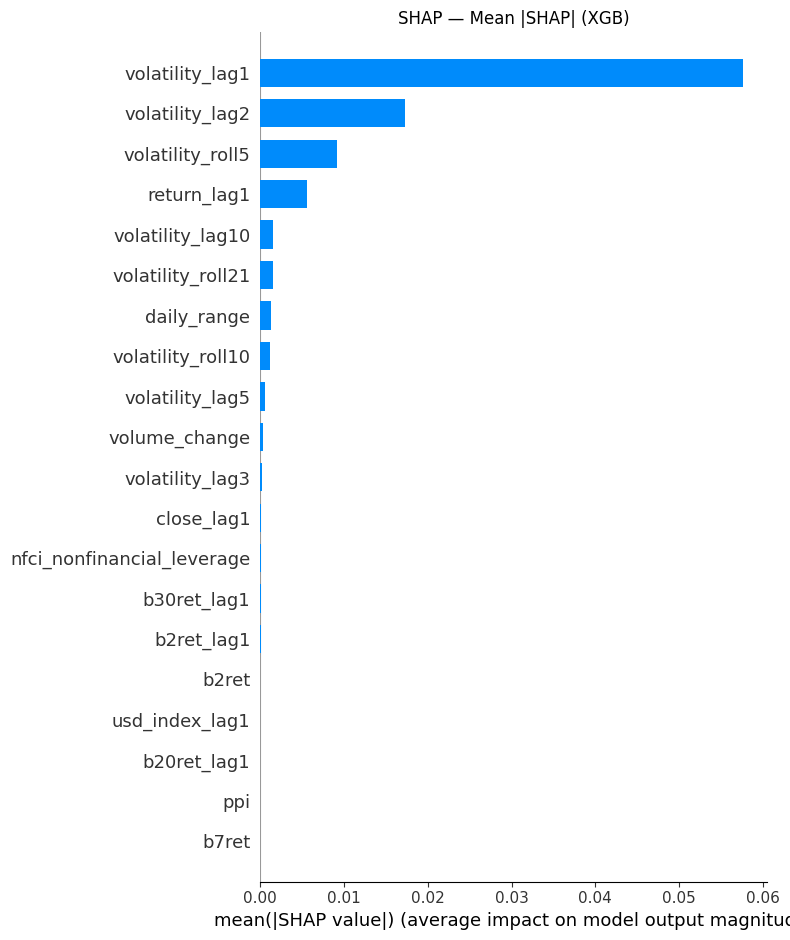

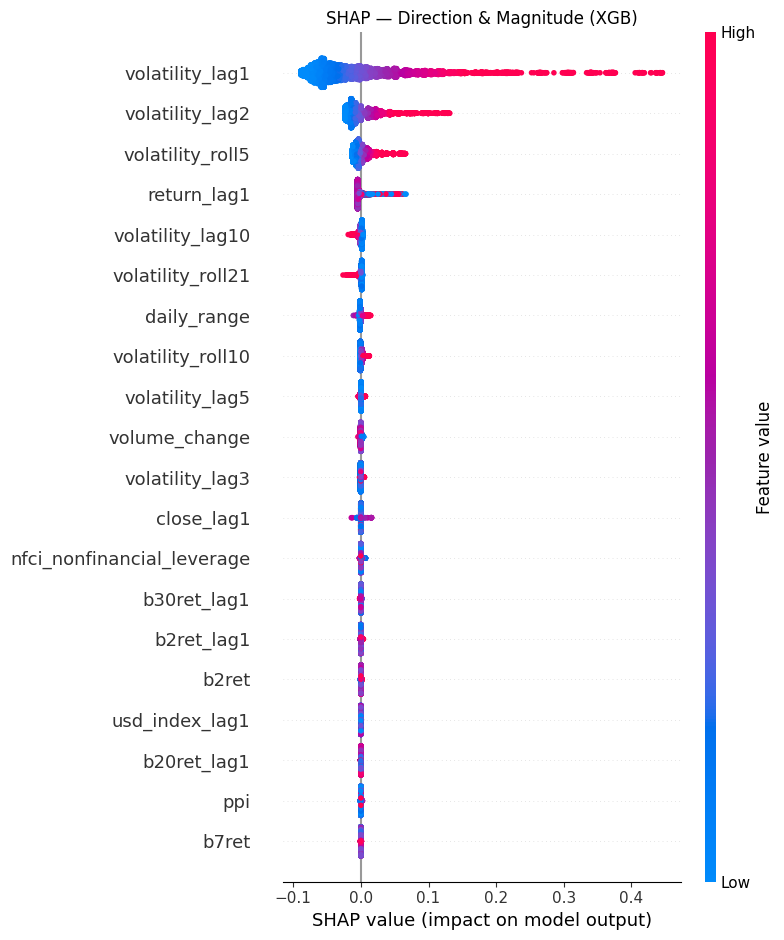

In [ ]:
results, rmse, mae, mape, r2, xgb_fi_std, xgb_fi_shap, xgb_fi_perm, xgb_fi_lime = Volatility_prediction(
    df,
    use_macro        = True,
    model            = 'XGB',
    use_scaling      = True,
    importance_strategy = 'shap',
    tune=False
)

### KNN

Total: 8774 | Train: 8522 | Test: 252 | Features: 12

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.106428     0.006792
2024-02-01          0.167210     0.162059     0.005151
2024-03-04          0.169070     0.189719     0.020649
2024-04-03          0.135562     0.138570     0.003008
2024-05-02          0.197198     0.172163     0.025035
2024-06-03          0.121509     0.137533     0.016024
2024-07-03          0.119741     0.114855     0.004886
2024-08-02          0.244631     0.229162     0.015468
2024-09-03          0.251129     0.264572     0.013444
2024-10-02          0.212546     0.209855     0.002691
2024-10-31          0.121384     0.113400     0.007984
2024-12-02          0.192293     0.149448     0.042845
  (showing every ~21 days)
-----------------------------------------------------------------
                                        RMSE:     0.019259
             

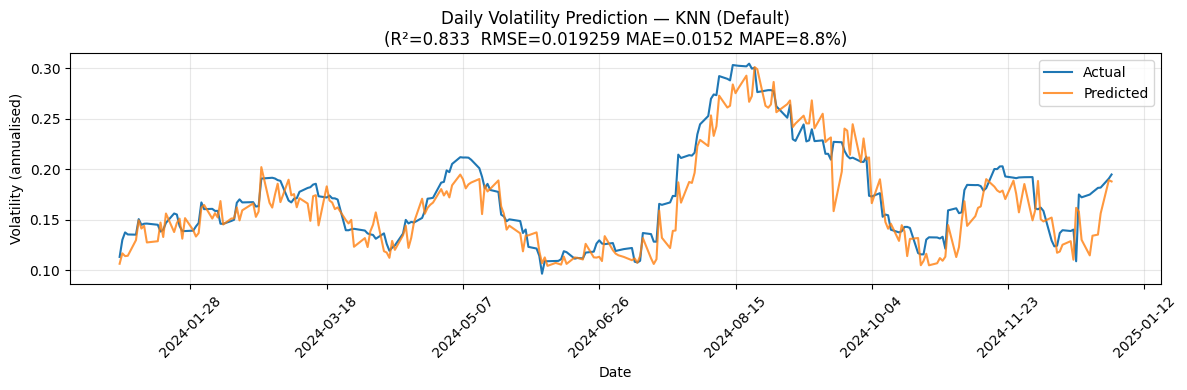

  0%|          | 0/8522 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
results, rmse, mae, mape, r2, knn_fi_std, knn_fi_shap, knn_fi_perm, knn_fi_lime = Volatility_prediction(
    df,
    use_macro        = False,
    model            = 'KNN',
    use_scaling      = True,
    importance_strategy = 'shap',
    tune=False
)

Total: 8774 | Train: 8522 | Test: 252 | Features: 59

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.134185     0.020965
2024-02-01          0.167210     0.159875     0.007335
2024-03-04          0.169070     0.166887     0.002183
2024-04-03          0.135562     0.164128     0.028566
2024-05-02          0.197198     0.146908     0.050289
2024-06-03          0.121509     0.155373     0.033863
2024-07-03          0.119741     0.114405     0.005336
2024-08-02          0.244631     0.166472     0.078159
2024-09-03          0.251129     0.189715     0.061414
2024-10-02          0.212546     0.227372     0.014826
2024-10-31          0.121384     0.162778     0.041393
2024-12-02          0.192293     0.155541     0.036752
  (showing every ~21 days)
-----------------------------------------------------------------
                                        RMSE:     0.044128
             

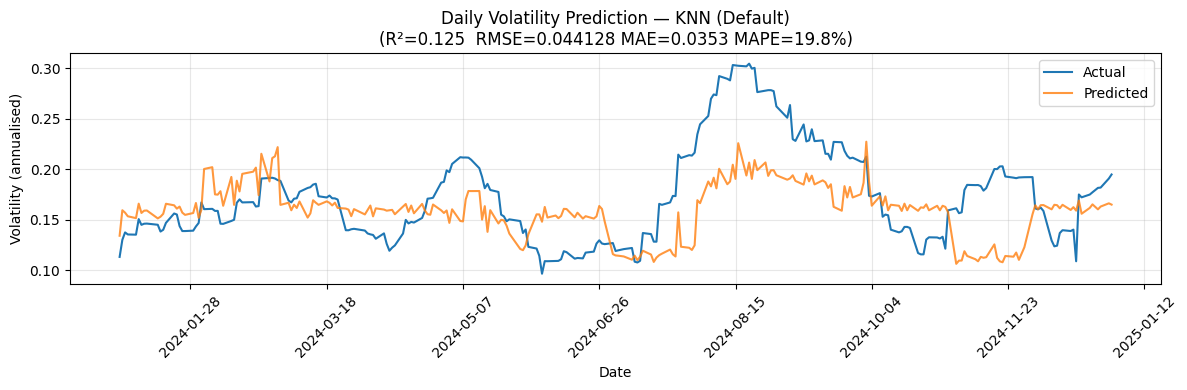

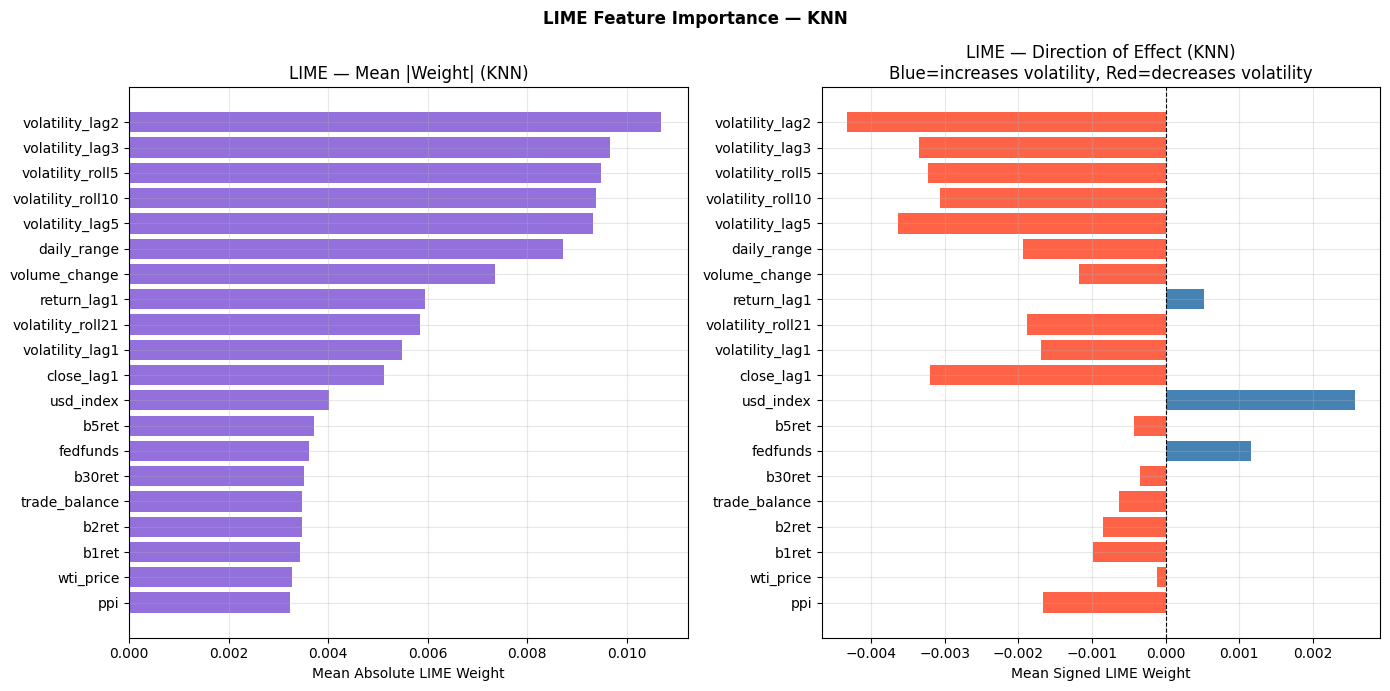

In [ ]:
results, rmse, mae, mape, r2, knn_fi_std, knn_fi_shap, knn_fi_perm, knn_fi_lime = Volatility_prediction(
    df,
    use_macro        = True,
    model            = 'KNN',
    use_scaling      = True,
    importance_strategy = 'lime',
    tune=False
)

### SVR

Total: 8774 | Train: 8522 | Test: 252 | Features: 12
['daily_range', 'volume_change', 'close_lag1', 'return_lag1', 'volatility_lag1', 'volatility_lag2', 'volatility_lag3', 'volatility_lag5', 'volatility_lag10', 'volatility_roll5', 'volatility_roll10', 'volatility_roll21']

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.106760     0.006460
2024-02-01          0.167210     0.165936     0.001274
2024-03-04          0.169070     0.181333     0.012263
2024-04-03          0.135562     0.127283     0.008279
2024-05-02          0.197198     0.184323     0.012875
2024-06-03          0.121509     0.113835     0.007674
2024-07-03          0.119741     0.121674     0.001933
2024-08-02          0.244631     0.235161     0.009470
2024-09-03          0.251129     0.261893     0.010765
2024-10-02          0.212546     0.187873     0.024673
2024-10-31          0.121384     0.116204     0.005180


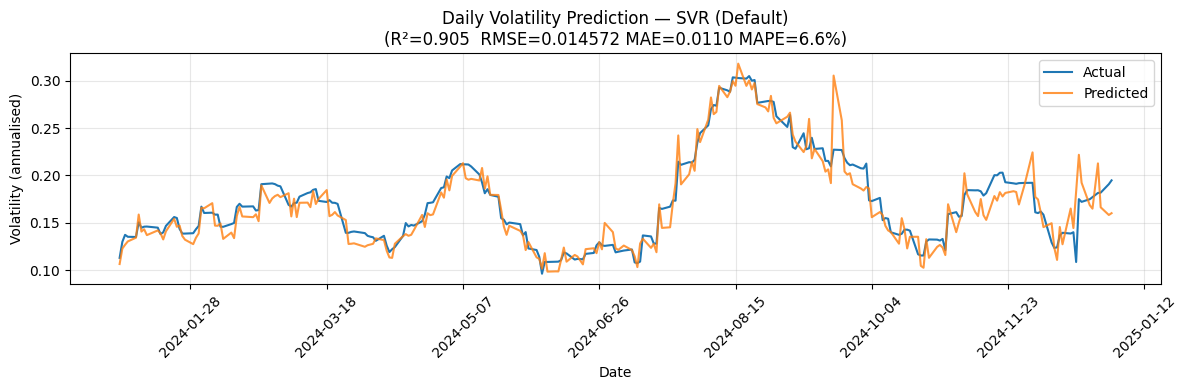

  0%|          | 0/8522 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
results, rmse, mae, mape, r2, svr_fi_std, svr_fi_shap, svr_fi_perm, svr_fi_lime = Volatility_prediction(
    df, use_macro=False, model='SVR',
    use_scaling=True,
    importance_strategy='shap',
    tune=False
)

Total: 8774 | Train: 8522 | Test: 252 | Features: 59

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.136773     0.023553
2024-02-01          0.167210     0.176240     0.009030
2024-03-04          0.169070     0.176278     0.007208
2024-04-03          0.135562     0.150843     0.015281
2024-05-02          0.197198     0.184832     0.012366
2024-06-03          0.121509     0.132787     0.011278
2024-07-03          0.119741     0.146997     0.027256
2024-08-02          0.244631     0.226147     0.018484
2024-09-03          0.251129     0.250828     0.000301
2024-10-02          0.212546     0.223153     0.010606
2024-10-31          0.121384     0.175702     0.054318
2024-12-02          0.192293     0.197523     0.005230
  (showing every ~21 days)
-----------------------------------------------------------------
                                        RMSE:     0.018951
             

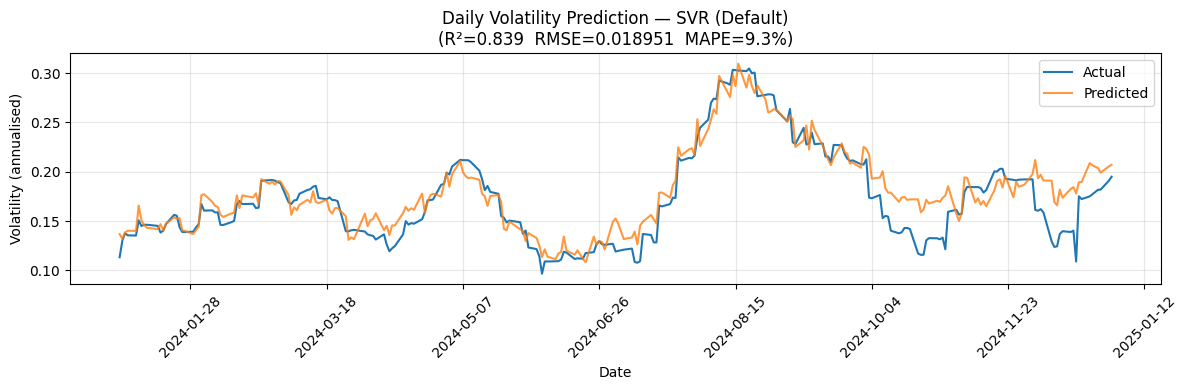

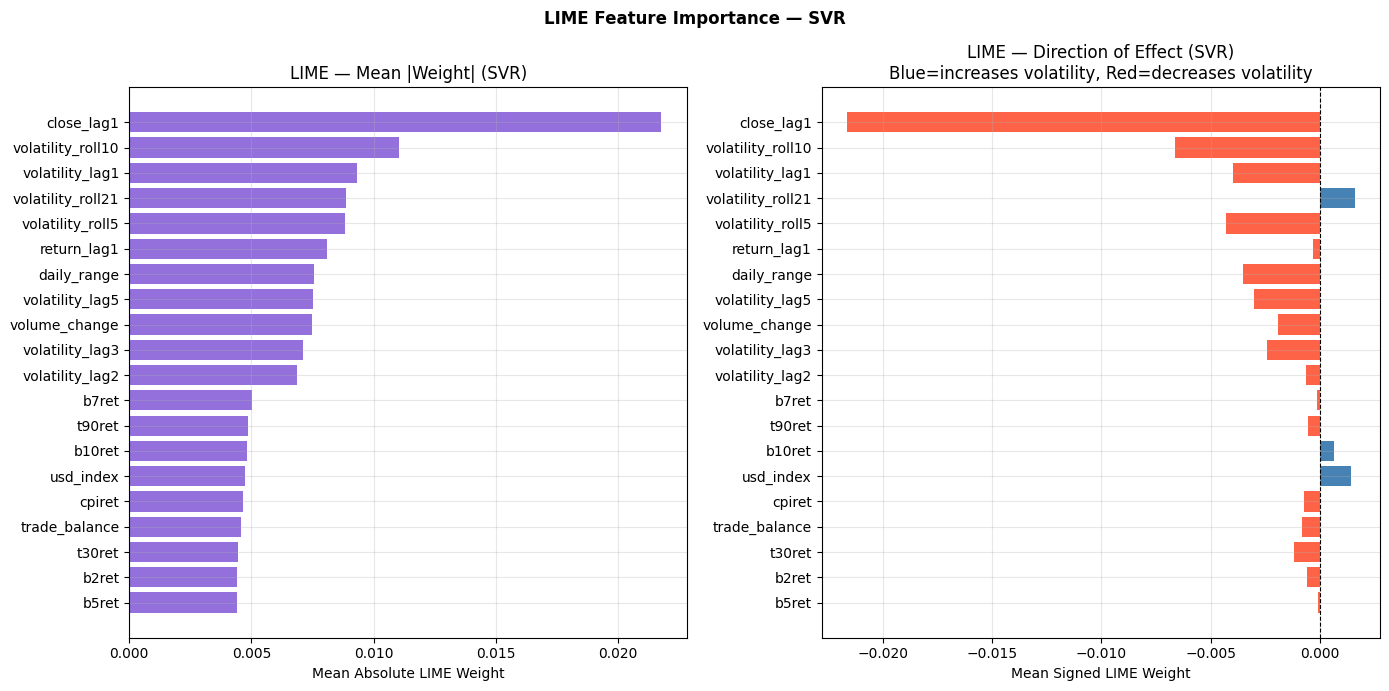

In [ ]:
results, rmse, mae, mape, r2, svr_fi_std, svr_fi_shap, svr_fi_perm, svr_fi_lime = Volatility_prediction(
    df, use_macro=True, model='SVR',
    use_scaling=True,
    importance_strategy='lime',
    tune=False
)

### Catboost

Total: 8774 | Train: 8522 | Test: 252 | Features: 12

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.111746     0.001474
2024-02-01          0.167210     0.159013     0.008197
2024-03-04          0.169070     0.187626     0.018556
2024-04-03          0.135562     0.138642     0.003080
2024-05-02          0.197198     0.193391     0.003807
2024-06-03          0.121509     0.126139     0.004629
2024-07-03          0.119741     0.123537     0.003796
2024-08-02          0.244631     0.238660     0.005971
2024-09-03          0.251129     0.262830     0.011701
2024-10-02          0.212546     0.208900     0.003647
2024-10-31          0.121384     0.130849     0.009464
2024-12-02          0.192293     0.192741     0.000448
  (showing every ~21 days)
-----------------------------------------------------------------
                                        RMSE:     0.008150
             

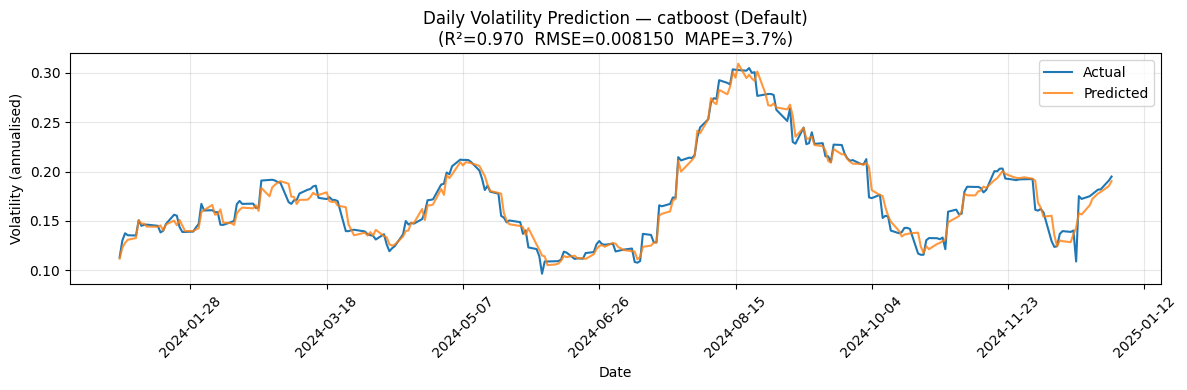

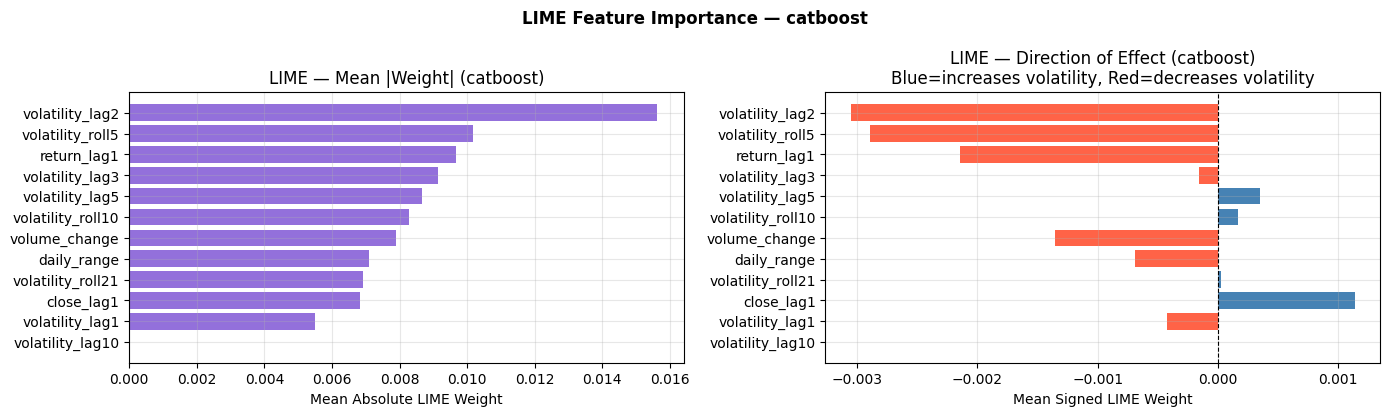

In [ ]:
results, rmse, mae, mape, r2, catboost_fi_std, catboost_fi_shap, catboost_fi_perm, catboost_fi_lime = Volatility_prediction(
    df, use_macro=False, model='catboost',
    use_scaling=True,
    importance_strategy='lime',
    tune=False
)

Total: 8774 | Train: 8522 | Test: 252 | Features: 59

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.109571     0.003649
2024-02-01          0.167210     0.162983     0.004227
2024-03-04          0.169070     0.189489     0.020419
2024-04-03          0.135562     0.135817     0.000255
2024-05-02          0.197198     0.191981     0.005217
2024-06-03          0.121509     0.126220     0.004710
2024-07-03          0.119741     0.122291     0.002551
2024-08-02          0.244631     0.239360     0.005271
2024-09-03          0.251129     0.268200     0.017072
2024-10-02          0.212546     0.207688     0.004858
2024-10-31          0.121384     0.131663     0.010279
2024-12-02          0.192293     0.189987     0.002307
  (showing every ~21 days)
-----------------------------------------------------------------
                                        RMSE:     0.007845
             

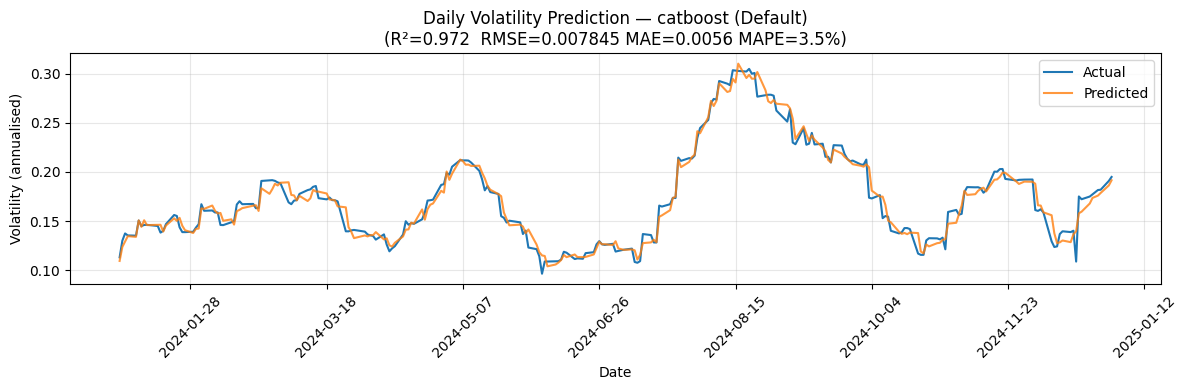

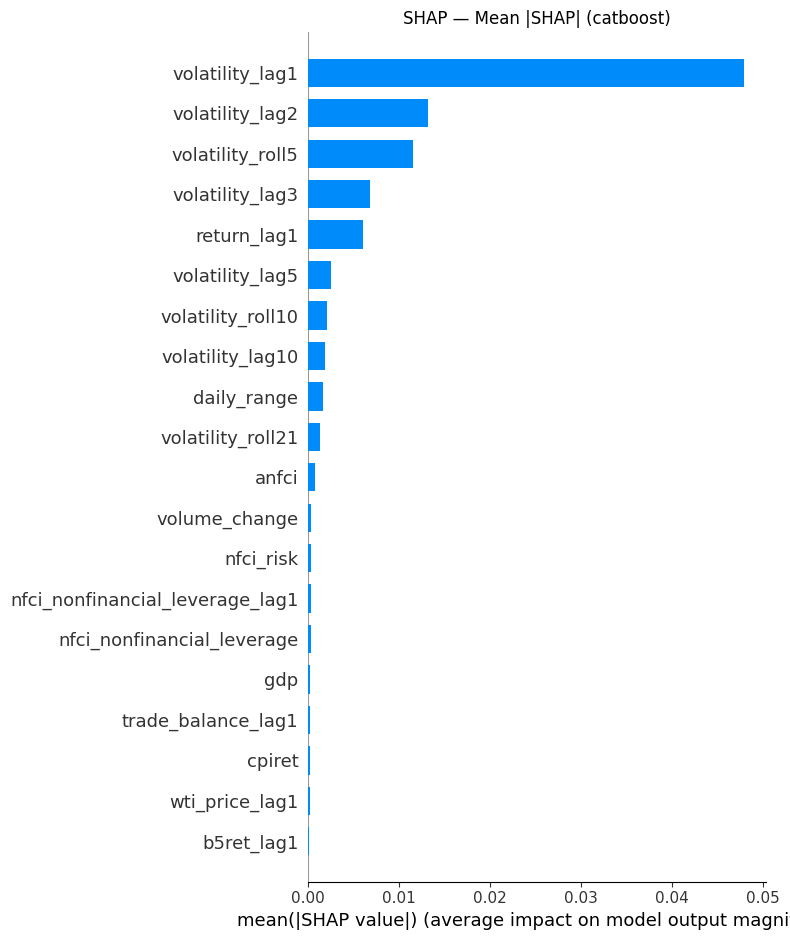

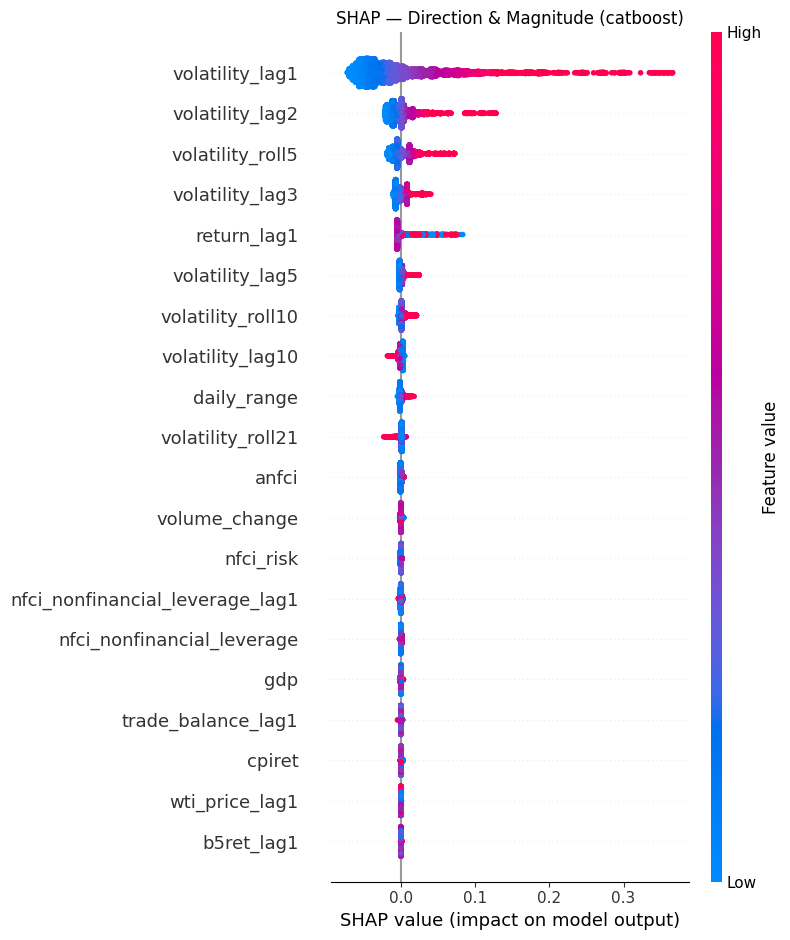

In [ ]:
results, rmse, mae, mape, r2, catboost_fi_std, catboost_fi_shap, catboost_fi_perm, catboost_fi_lime = Volatility_prediction(
    df, use_macro=True, model='catboost',
    use_scaling=True,
    importance_strategy='shap',
    tune=False
)

### Arima

Total: 8774 | Train: 8522 | Test: 252 | Features: 12
['daily_range', 'volume_change', 'close_lag1', 'return_lag1', 'volatility_lag1', 'volatility_lag2', 'volatility_lag3', 'volatility_lag5', 'volatility_lag10', 'volatility_roll5', 'volatility_roll10', 'volatility_roll21']


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



ARIMA — Best AIC: -49673.55
                                        RMSE:     0.077127
                                         MAE:  0.06133930178846854
                                    MAPE (%): (31.20253990624107,)
                                          R²: -1.6722777170576686

Note: ARIMA feature importance not applicable — AR/MA coefficients:
ar.L1      0.758174
ar.L2      0.058665
ma.L1     -0.696497
ar.S.L5    0.008372
sigma2     0.000171
dtype: float64


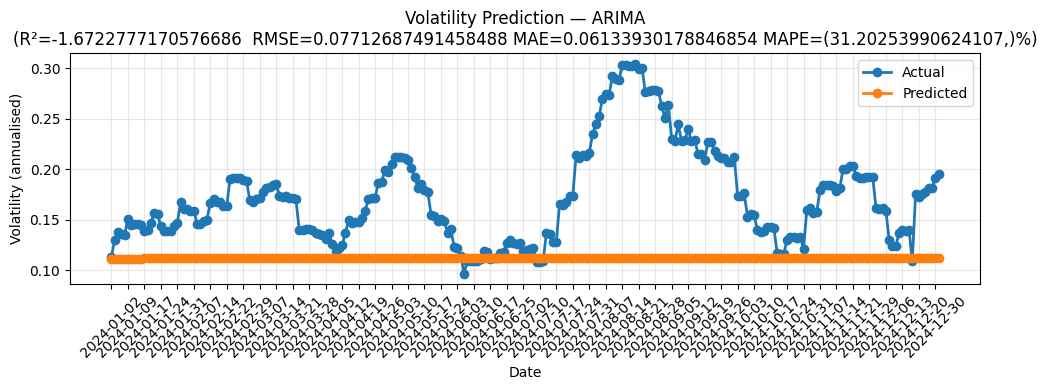

In [ ]:
results, rmse, mae, mape, r2 = Volatility_prediction(
    df, use_macro=False, model='arima',
    use_scaling=True
)

Total: 8774 | Train: 8522 | Test: 252 | Features: 59


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op


ARIMA — Best AIC: -50419.14
Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2024-01-02          0.113220     0.102174     0.011046
2024-01-03          0.130131     0.115169     0.014962
2024-01-04          0.137511     0.132335     0.005176
2024-01-05          0.135465     0.141280     0.005815
2024-01-08          0.135260     0.141325     0.006065
2024-01-09          0.150660     0.141406     0.009254
2024-01-10          0.144992     0.155019     0.010028
2024-01-11          0.146107     0.151739     0.005632
2024-01-12          0.146237     0.148065     0.001827
2024-01-16          0.145068     0.147861     0.002794
2024-01-17          0.138329     0.149260     0.010931
2024-01-18          0.140121     0.140842     0.000720
2024-01-19          0.146960     0.145016     0.001943
2024-01-22          0.156244     0.149575     0.006670
2024-01-23          0.155237     0.157919     0.002682
2024-01-24          0.143

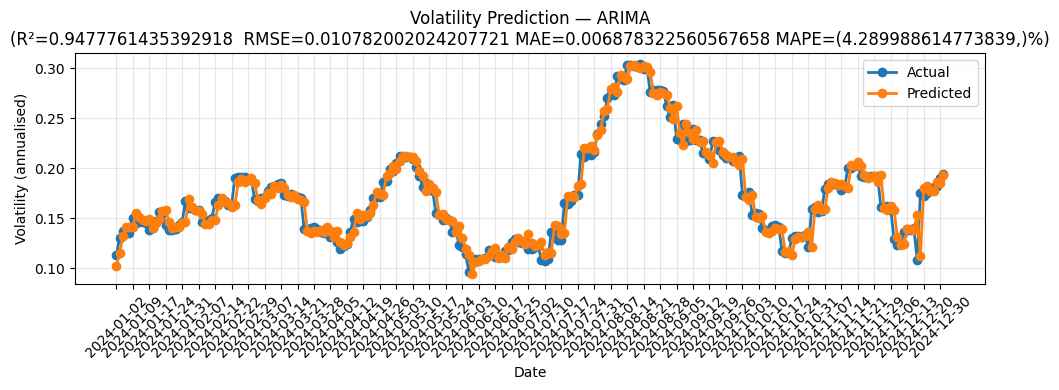

In [ ]:
results, rmse, mae, mape, r2 = Volatility_prediction(
    df, use_macro=True, model='arima',
    use_scaling=True,
    tune=False,
)

## Aggregate feature importance

In [ ]:
def _classify(feature: str) -> str:
    base = feature.replace("_lag1", "").replace("_lag2", "").replace("_lag4", "")
    return "macro" if base in macro_vars else "micro"

In [ ]:

def _build_matrices(importance_results: dict):
    model_names  = list(importance_results.keys())
    n_models     = len(model_names)

    all_features = sorted(
        set(f for fi in importance_results.values() for f in fi['feature'])
    )
    n_features = len(all_features)

    rank_matrix  = pd.DataFrame(index=all_features, columns=model_names, dtype=float)
    score_matrix = pd.DataFrame(index=all_features, columns=model_names, dtype=float)

    for model_name, fi_df in importance_results.items():
        fi_df = fi_df.copy().reset_index(drop=True)
        fi_df['rank'] = fi_df['importance'].rank(ascending=False, method='min')

        imp_min = fi_df['importance'].min()
        imp_max = fi_df['importance'].max()
        denom   = imp_max - imp_min if imp_max != imp_min else 1.0
        fi_df['norm_score'] = (fi_df['importance'] - imp_min) / denom

        for _, row in fi_df.iterrows():
            rank_matrix.loc[row['feature'],  model_name] = row['rank']
            score_matrix.loc[row['feature'], model_name] = row['norm_score']

        for f in set(all_features) - set(fi_df['feature']):
            rank_matrix.loc[f,  model_name] = n_features + 1
            score_matrix.loc[f, model_name] = 0.0

    return model_names, all_features, n_features, rank_matrix, score_matrix

In [ ]:
def _compute_all_methods(model_names, all_features, n_features,
                          rank_matrix, score_matrix) -> pd.DataFrame:
    # Borda
    borda_scores = sum(
        (n_features + 1) - rank_matrix[m] for m in model_names
    )

    # Mean rank
    mean_rank = rank_matrix.mean(axis=1)
    std_rank  = rank_matrix.std(axis=1)

    # Mean normalised score
    mean_score = score_matrix.mean(axis=1)
    std_score  = score_matrix.std(axis=1)

    combined = pd.DataFrame({
        'feature':          all_features,
        'borda_score':      borda_scores.values,
        'mean_rank':        mean_rank.values,
        'std_rank':         std_rank.values,
        'mean_score':       mean_score.values,
        'std_score':        std_score.values,
        'consistency':      (1 / (std_rank.values + 1e-6)),
        'var_group':        [_classify(f) for f in all_features],
    })
    return combined


def _plot_group(ax, features, scores, errs, title, xlabel,
                color, invert_x=False, method_key='borda'):
    if len(features) == 0:
        ax.text(0.5, 0.5, 'No features in this group',
                ha='center', va='center', transform=ax.transAxes, fontsize=10)
        ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
        return

    y = range(len(features))
    if errs is not None:
        ax.barh(list(y), scores, xerr=errs, color=color,
                alpha=0.85, capsize=3, edgecolor='white', linewidth=0.4)
    else:
        ax.barh(list(y), scores, color=color,
                alpha=0.85, edgecolor='white', linewidth=0.4)

    ax.set_yticks(list(y))
    ax.set_yticklabels(features, fontsize=8)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    if invert_x:
        ax.invert_xaxis()
    ax.grid(True, axis='x', alpha=0.25, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

    # Inline value labels
    for i, (s, feat) in enumerate(zip(scores, features)):
        ax.text(s * (0.98 if not invert_x else 1.02),
                i, f"{s:.3f}", va='center',
                ha='right' if not invert_x else 'left',
                fontsize=7, color='#333333')


def aggregate_feature_importance(importance_results: dict,
                                  top_n: int = 20) -> pd.DataFrame:
    model_names, all_features, n_features, rank_matrix, score_matrix = \
        _build_matrices(importance_results)

    combined = _compute_all_methods(
        model_names, all_features, n_features, rank_matrix, score_matrix
    )

    n_models = len(model_names)

    for method_key, sort_col, ascending, label in [
        ('borda',      'borda_score', False, 'BORDA COUNT'),
        ('mean_rank',  'mean_rank',   True,  'MEAN RANK'),
        ('mean_score', 'mean_score',  False, 'MEAN NORMALISED SCORE'),
    ]:
        ranked = combined.sort_values(sort_col, ascending=ascending).head(top_n)
        print(f"\n{'='*75}")
        print(f"AGGREGATED FEATURE IMPORTANCE — {label} ({n_models} models)")
        print(f"{'='*75}")
        print(f"{'Rank':<6} {'Feature':<35} {'Borda':>8} "
              f"{'MeanRank':>10} {'MeanScore':>10} {'Group':>7}")
        print(f"{'-'*75}")
        for i, (_, row) in enumerate(ranked.iterrows()):
            print(f"{i+1:<6} {row['feature']:<35} "
                  f"{row['borda_score']:>8.1f} "
                  f"{row['mean_rank']:>10.2f} "
                  f"{row['mean_score']:>10.4f} "
                  f"{row['var_group']:>7}")
        print(f"{'='*75}")

    METHOD_CFG = [
        ('borda_score', False, 'borda_score', None,
         'Borda Score (higher = more important)',
         '#2E86AB', False, 'Borda Count'),

        ('mean_rank', True, 'mean_rank', 'std_rank',
         'Mean Rank (lower = more important, ±std)',
         '#E07A5F', True, 'Mean Rank'),

        ('mean_score', False, 'mean_score', 'std_score',
         'Mean Normalised Score (higher = more important, ±std)',
         '#3D9970', False, 'Mean Norm. Score'),
    ]

    GROUPS = [
        ('macro', 'Macro Variables'),
        ('micro', 'Micro Variables'),
    ]

    fig, axes = plt.subplots(
        3, 2,
        figsize=(18, top_n * 0.55 + 3),
        constrained_layout=True
    )

    fig.suptitle(
        f'Feature Importance Aggregation',
        fontsize=13, fontweight='bold', y=1.01
    )

    for row_idx, (sort_col, ascending, score_col, err_col,
                  xlabel, color, invert_x, method_label) in enumerate(METHOD_CFG):

        for col_idx, (group_key, group_label) in enumerate(GROUPS):

            ax = axes[row_idx][col_idx]

            # Filter to this variable group, sort by this method
            subset = (combined[combined['var_group'] == group_key]
                      .sort_values(sort_col, ascending=ascending)
                      .head(top_n))

            features = subset['feature'].tolist()[::-1]   # flip for barh
            scores   = subset[score_col].tolist()[::-1]
            errs     = subset[err_col].tolist()[::-1] if err_col else None

            title = f"{method_label}  |  {group_label}"
            _plot_group(ax, features, scores, errs,
                        title, xlabel, color, invert_x, method_key=sort_col)

    plt.savefig("feature_importance_Volatility.png", dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()

    return combined


def plot_model_agreement(importance_results: dict, top_n: int):
    model_names = list(importance_results.keys())
    vote_counts = {}

    for model_name, fi_df in importance_results.items():
        for f in fi_df.nlargest(top_n, 'importance')['feature']:
            vote_counts[f] = vote_counts.get(f, 0) + 1

    vote_df = (pd.DataFrame({
        'feature': list(vote_counts.keys()),
        'votes':   list(vote_counts.values()),
        'group':   [_classify(f) for f in vote_counts]
    }).sort_values('votes', ascending=False).reset_index(drop=True))

    print(f"\n{'='*55}")
    print(f"MODEL AGREEMENT — Top {top_n} features per model")
    print(f"{'='*55}")
    for _, row in vote_df.iterrows():
        bar = '█' * row['votes']
        pct = row['votes'] / len(model_names) * 100
        print(f"  {row['feature']:<30} {bar:<10} "
              f"{row['votes']}/{len(model_names)} ({pct:.0f}%)  [{row['group']}]")
    print(f"{'='*55}")

    fig, ax = plt.subplots(figsize=(8, max(4, len(vote_df) * 0.35)))
    colors = ['darkgreen' if v == len(model_names)
              else 'steelblue' if v >= len(model_names) * 0.6
              else 'salmon'
              for v in vote_df['votes'][::-1]]
    ax.barh(vote_df['feature'][::-1], vote_df['votes'][::-1], color=colors)
    ax.axvline(len(model_names), color='black', linestyle='--',
               linewidth=1, label=f'All {len(model_names)} models')
    ax.axvline(len(model_names) * 0.6, color='orange', linestyle='--',
               linewidth=1, label='60% of models')
    ax.set_xlabel(f"Number of models featuring in top {top_n}")
    ax.set_title(f"Feature Agreement Across Models\n"
                 f"(green = in top {top_n} of ALL models)")
    ax.set_xlim(0, len(model_names) + 0.5)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return vote_df


AGGREGATED FEATURE IMPORTANCE — BORDA COUNT (4 models)
Rank   Feature                                Borda   MeanRank  MeanScore   Group
---------------------------------------------------------------------------
1      volatility_lag1                        236.0       1.00     1.0000   micro
2      return_lag1                            227.0       3.25     0.0737   micro
3      volatility_lag2                        226.0       3.50     0.1450   micro
4      daily_range                            217.0       5.75     0.0172   micro
5      volatility_lag10                       212.0       7.00     0.0174   micro
6      volatility_roll5                       212.0       7.00     0.1002   micro
7      volatility_roll21                      210.0       7.50     0.0169   micro
8      volatility_lag5                        203.0       9.25     0.0160   micro
9      volatility_roll10                      201.0       9.75     0.0162   micro
10     volatility_lag3                        19

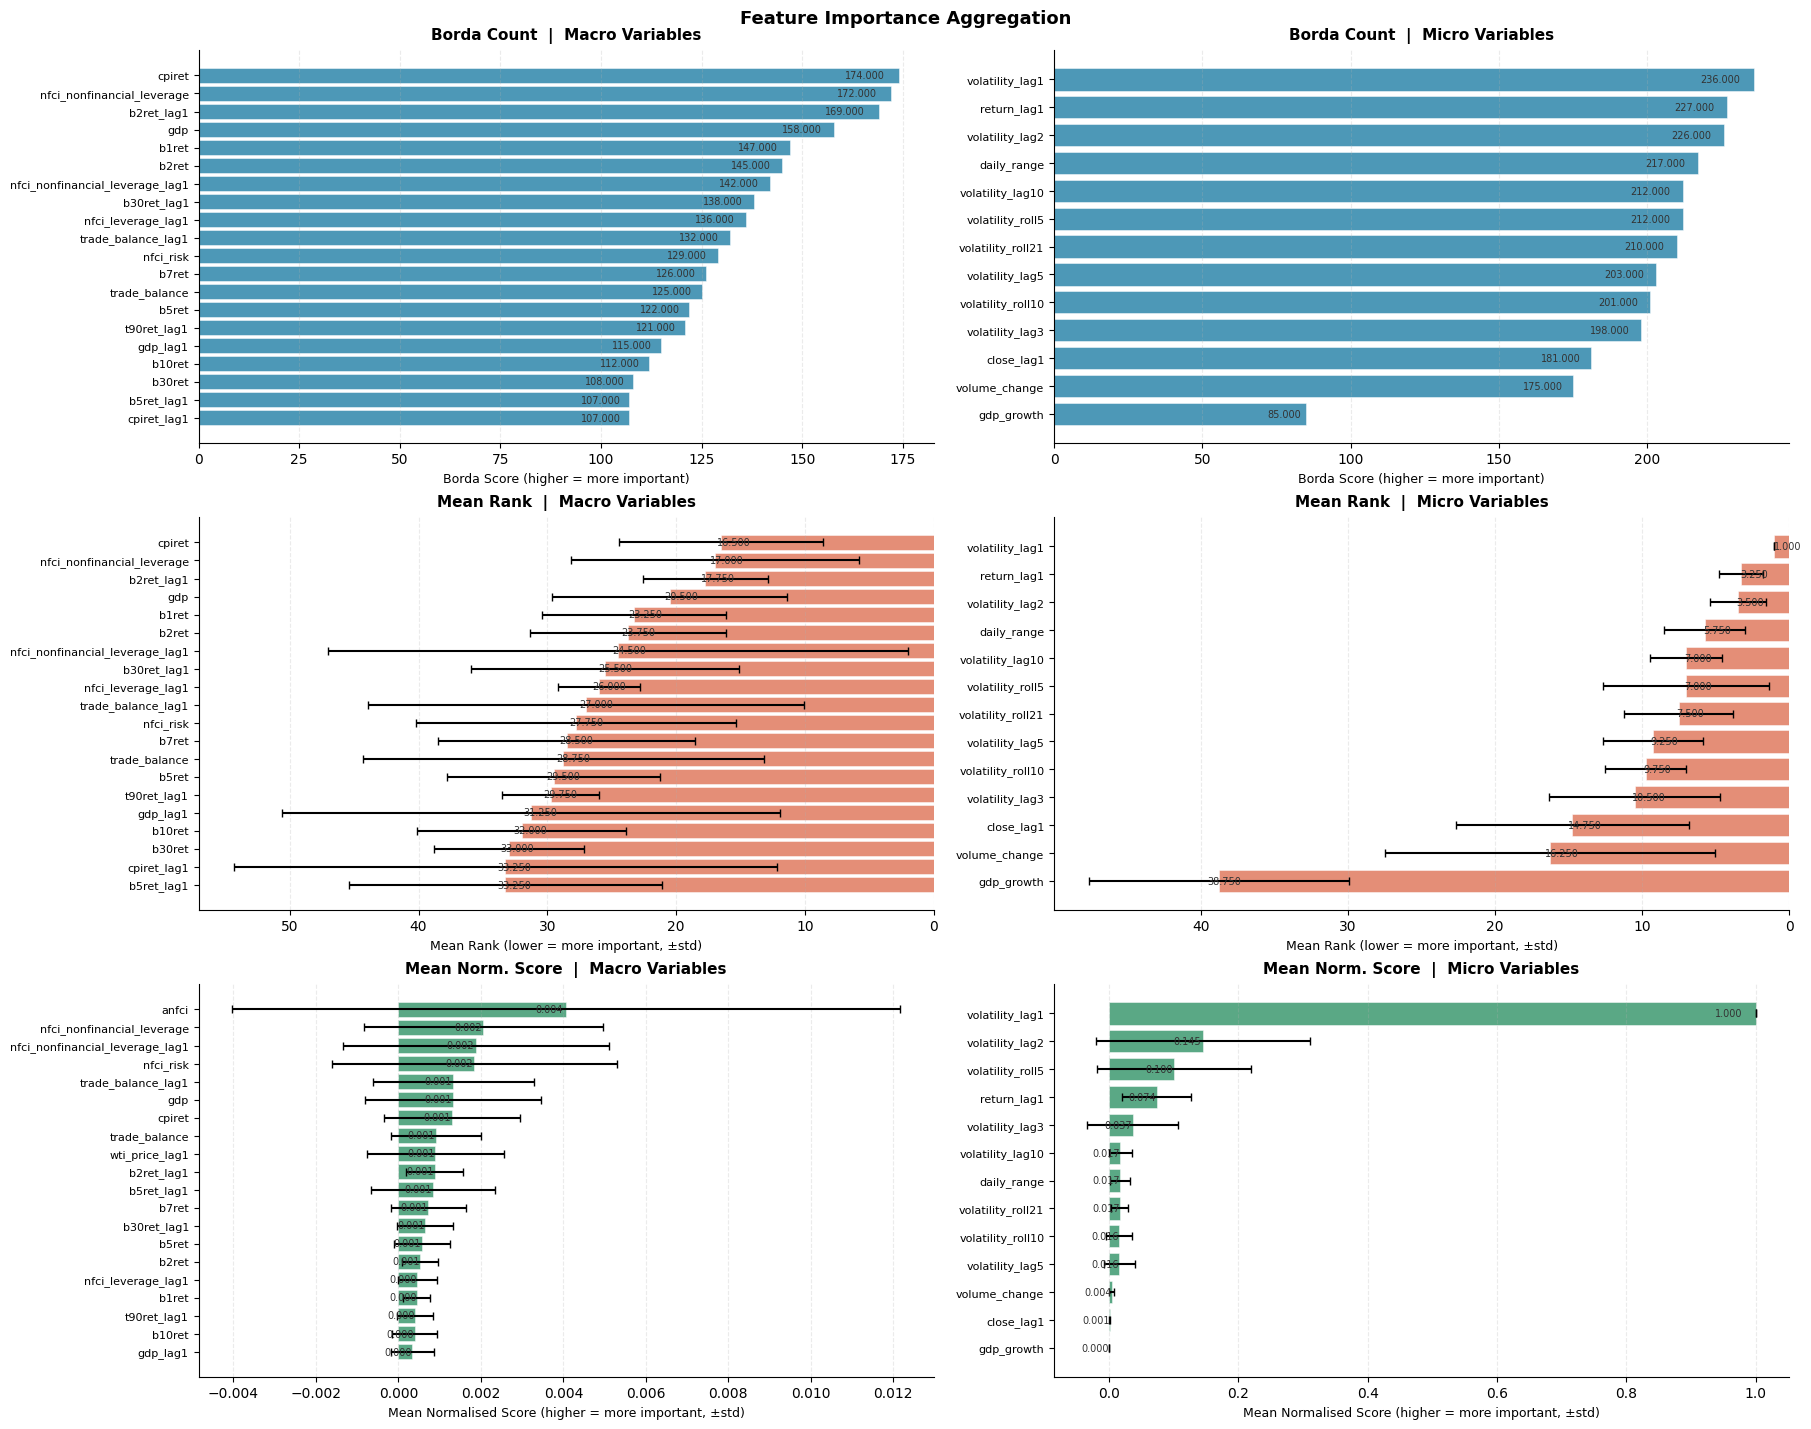


MODEL AGREEMENT — Top 10 features per model
  volatility_lag1                ████       4/4 (100%)  [micro]
  volatility_lag2                ████       4/4 (100%)  [micro]
  return_lag1                    ████       4/4 (100%)  [micro]
  volatility_lag10               ████       4/4 (100%)  [micro]
  daily_range                    ████       4/4 (100%)  [micro]
  volatility_roll5               ███        3/4 (75%)  [micro]
  volatility_roll21              ███        3/4 (75%)  [micro]
  volatility_lag5                ███        3/4 (75%)  [micro]
  volatility_roll10              ██         2/4 (50%)  [micro]
  volume_change                  ██         2/4 (50%)  [micro]
  volatility_lag3                ██         2/4 (50%)  [micro]
  close_lag1                     █          1/4 (25%)  [micro]
  nfci_nonfinancial_leverage_lag1 █          1/4 (25%)  [macro]
  nfci_nonfinancial_leverage     █          1/4 (25%)  [macro]
  gdp_lag1                       █          1/4 (25%)  [macro]
  cp

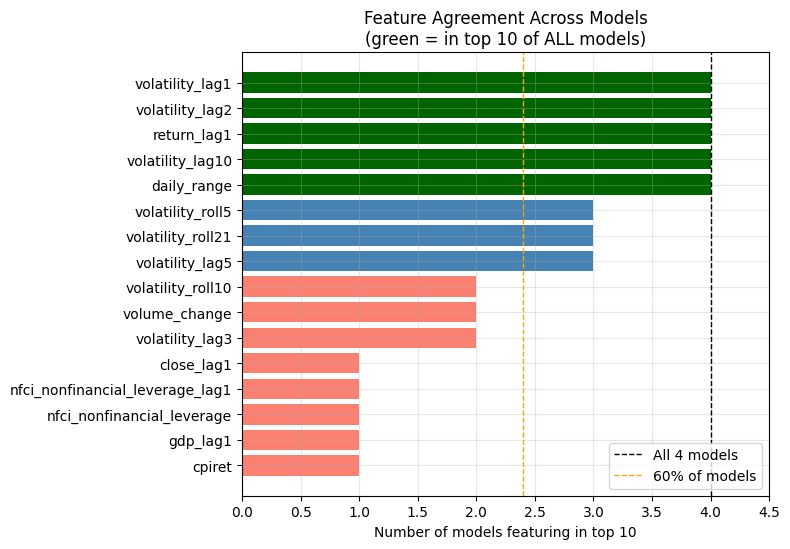

In [ ]:
importance_results = {
    'XGB':      xgb_fi_shap,
    'GB':       gb_fi_shap,
    # 'bayes':    bayes_fi_lime,
    'catboost': catboost_fi_shap,
    'RF': rf_fi_shap,
    #'KNN': knn_fi_shap,
    #'SVR' :svr_fi_shap
}

aggregated = aggregate_feature_importance(
    importance_results,
    top_n=20
)

vote_df = plot_model_agreement(importance_results, top_n=10)